<h2><span style="color:#455a64;">Декомпозиция</span></h2>
<p><span style="color:#455a64;">Предоставленный датасет описывает транзакции интернет-магазина товаров для дома и быта «Пока все ещё тут».<br></span></p>
    <p><span style="color:#455a64;">Колонки в ecom_dataset_upd.csv :</span></p>
<ul>
    <li><span style="color:#455a64;">date — дата заказа;</span></li>
    <li><span style="color:#455a64;">customer_id — идентификатор покупателя;</span></li>
    <li><span style="color:#455a64;">order_id — идентификатор заказа;</span></li>
    <li><span style="color:#455a64;">product — наименование товара;</span></li>
    <li><span style="color:#455a64;">quantity — количество товара в заказе;</span></li>
    <li><span style="color:#455a64;">price — цена товара.</span></li>
</ul>
<p><span style="color:#455a64;">
Основная, главная задача проекта - сегментация пользователей по профилю потребления.<br>
Требуется провести исследовательский анализ данных и сегментировать покупателей на основе истории их покупок.<br>
На основе полученной сегментации предложить варианты разработки персонализированных предложений для клиентов.</span></p>
<p><span style="color:#455a64;">Исследование будет проходить по следующим этапам с выполнением промежуточных целей:</span></p>

<h3><span style="color:#455a64;">Загрузка и предобработка данных:</span></h3>
<ul>
   <li><span style="color:#455a64;">Оценка “сырых” данных;</span></li>
   <li><span style="color:#455a64;">Приведение типов колонок в соответствие с содержимым, переименование колонок при необходимости;</span></li>
   <li><span style="color:#455a64;">Поиск пропусков в данных. Выбор стратегии их обработки;</span></li>
   <li><span style="color:#455a64;">Проверка на наличие дубликатов. Очистка от дублей;</span></li>
   <li><span style="color:#455a64;">Анализ данных на предмет аномалий и выбросов. Отсеивание этих записей;</span></li>
   <li><span style="color:#455a64;">Добавление новых колонок: помимо колонки с выявленной категорией товара, я добавляю колонку с датой первого заказа у каждого пользователя. Считаем эту дату датой регистрации пользователя;</span></li>
   <li><span style="color:#455a64;">Осмотр датафрейма после проведенных манипуляций;</span></li>
    </ul>
<p><span style="color:#455a64;">В результате того этапа мы получаем чистые данные, готовые к анализу.</span></p>

<h3><span style="color:#455a64;">Анализ данных. Попробуем определить следующие моменты:</span></h3>
<ul>
    <li><span style="color:#455a64;">Среднее количество заказов на одного покупателя</span></li>
    <li><span style="color:#455a64;">Средняя сумма заказа</span></li>
    <li><span style="color:#455a64;">Средняя стоимость товаров в зависимости от категории товара</span></li>
    <li><span style="color:#455a64;">Наиболее продаваемые категории товаров</span></li>
    <li><span style="color:#455a64;">Распределение категорий товаров в выручке компании</span></li>
    <li><span style="color:#455a64;">Наличие сезонности в продаже категорий товаров</span></li>
</ul>

<h3><span style="color:#455a64;">Сегментация покупателей и проверка гипотез:</span></h3>
<ul>
    <li><span style="color:#455a64;">Сегментация покупателей.<br>Для сегментации пользователей планирую использовать KMeans. Почему не RFM? Методика RFM требует понимания параметров бизнеса: какая последняя покупка может считаться старой, а какая - новой? сколько покупок мало, а сколько - много? общая сумма, потраченных денег покупателем когда становится большой? К сожалению, получить ответы на эти вопросы не получится. Поэтому KMeans. <b>Количество кластеров выберем методом "локтя".</b>
        <br><b>Для таблицы, которая будет отбрабатываться KMeans-методом создадим еще дополнительный "усреденный" датафрейм:<br>
        - идентификатор пользователя,<br>
        - средний чек(сумма покупок, деленная на количество заказов),<br>
        - среднее количество заказов(количество заказов, деленное на количество дней, прошедшим между первой и последней покупкам(или правильнее брать период с первой покупки по "текущий" момент?)),<br>
        - среднее количество товаров в чеке(количество купленных товаров, деленное на количество заказов),<br>
        - средняя стоимость товаров в чеке(сумма товаров в чеке, деленная на их количество в чеке),<br>
        - средняя "стоимость" клиента(сумма покупок, деленная на количество дней, прошедшим между первой покупкой и текущим днем)
        </b></span></li>
    <li>
        <p><span style="color:#455a64;">Проверка гипотез для оценки корректности разбиения на кластеры.<br>Т.к. датафрейм у нас довольно маленький, alpha предполагается использовать со значением 0.01. Статистический тест - тест Стьюдента для независимых выборок, проведенный попарно по столбцам, соответствующим заданию в гипотезах. </span></p>
                <p><span style="color:#455a64;">а) Н<sub>0 </sub>Средний чек покупки статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">&nbsp; &nbsp; H<sub>1</sub> Средний чек статистически отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">б)Н<sub>0</sub> Среднее количество приобретаемых товаров в кластерах статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">&nbsp; &nbsp;Н<sub>1</sub> Среднее количество приобретаемых товаров статистически отличается между кластерами.</span></p>
        <p><span style="color:#455a64;">в)Н<sub>0</sub> Среднее количество заказов(чеков) на одного покупателя статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">&nbsp; &nbsp;Н<sub>1</sub> Среднее количество заказов(чеков) на одного покупателя статистически отличается между кластерами.</span></p>
            </li>
        </ul>
            <span style="color:#455a64;">На основе результатов сегментации и проверки гипотез составляем варианты персонализированных, возможно, сезонных предложений для активных клиентов, рекламных рассылок(с со скидками или без на определенные группы товаров (какие - может дать ответ сегментация)) пользователям, которые требуют внимания из-за опасности оттока. </span>

<h2><span style="color:#455a64;">Предобработка данных</span></h2>

In [1]:
# импорт библиотек, используемых в работе

import pandas as pd
import datetime as dt
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.dates import MonthLocator
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats
from scipy.stats import shapiro
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.ticker import FormatStrFormatter


pd.set_option('display.max_colwidth', None) # чтобы длинные значения в ячейках не обрезались

<h3><span style="color:#455a64;">Оценка 'cырых' данных</span></h3>

In [2]:
# загружаем предоставленный файл с данными в датафрейм data

data = pd.read_csv('https://code.s3.yandex.net/datasets/ecom_dataset_upd.csv')

In [3]:
display(data.head()) # смотрим, как выглядят данные
print(data.info()) # смотрим типы данных и заполенность файла

,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12, h25",1,194.0
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         7474 non-null   int64  
 1   customer_id  7474 non-null   object 
 2   order_id     7474 non-null   int64  
 3   product      7474 non-null   object 
 4   quantity     7474 non-null   int64  
 5   price        7474 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 350.5+ KB
None


<h3><span style="color:#455a64;">Приведение типов колонок в соответствие с содержимым</span></h3>

<p><span style="color:#455a64;">Нужно перевести дату из числового формата в формат даты, но так как в текущих значениях даты у нас есть какое-то доп.значение после номера дня, нужно задать формат и флаг, что базовая строка содержит в себе дату, но не состоит полностью из нее.</span></p>

In [4]:
data['date'] = pd.to_datetime(data['date'],format='%Y%m%d',exact=False) # преобразование типа данных к datetime

<h3><span style="color:#455a64;">Пропуски</span></h3>

<p><span style="color:#455a64;">При выводе информации о датафреймы было определено, что пропусков в данных нет. Все ячейки заполнены.</span></p>

<h3><span style="color:#455a64;">Дубликаты</span></h3>

In [5]:
print('Количество явных дубликатов:',data.duplicated().sum())

Количество явных дубликатов: 966


In [6]:
# удаляем дубликаты
data = data.drop_duplicates()

<p><span style="color:#455a64;">Проверим неявные дубликаты, обработав столбец 'product'</span></p>

In [7]:
# определяем функцию для "нормализации" строки

def normalize_string(string):

    string = (
            string
                .lower() # понижаем регистр
                .strip() # удяляем пробелы в начале и в конце
                .replace('  ',' ') # заменяем возможные два пробела на один
        )
    return string # возвращаем "нормализованную" строку

In [8]:
temp_data = data.copy() # создадим копию рабочего датафрейма
temp_data['product'] = temp_data['product'].apply(normalize_string) # обработаем в нем столбец 'product'
print('Количество новых, неявных дубликатов:',temp_data.duplicated().sum()) # проверим дубликаты

Количество новых, неявных дубликатов: 0


<p><span style="color:#455a64;">Новых, неявных дубликатов не найдено</span></p>

In [9]:
del temp_data # удаялем ненужный более датафрейм

<p><span style="color:#455a64;">Помимо этого, у нас есть строки, отличающиеся только датой, в остальном полностью идентичные. Их принимаем за ошибку передачи данных и удаляем эти дубли.<br>
    Пример ниже:</span></p>

In [10]:
display(data[data.drop('date',axis=1).duplicated()].head())
print(f'Дубликаты без учета даты: {data.drop("date",axis=1).duplicated().sum()}')

,date,customer_id,order_id,product,quantity,price
58,2018-10-02,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 см металлическая сетка 35748W,1,3299.0
63,2018-10-03,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 см металлическая сетка 35748W,1,3299.0
152,2018-10-09,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 15,0 л пищевой овальный ""Ekko"" 2775, 1404032",1,209.0
153,2018-10-09,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 18,0 л пищевой (Иж), 1404047",1,194.0
154,2018-10-09,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 20,0 л пищевой (Минеральные воды), 1404045",1,277.0


Дубликаты без учета даты: 898


In [11]:
data[data['order_id']==68474]

,date,customer_id,order_id,product,quantity,price
19,2018-10-01,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 см металлическая сетка 35748W,1,3299.0
58,2018-10-02,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 см металлическая сетка 35748W,1,3299.0
63,2018-10-03,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 см металлическая сетка 35748W,1,3299.0


In [12]:
# удаляем дубли без учета столбца даты

data = data.drop(data[data.drop('date',axis=1).duplicated()].index)

<h3><span style="color:#455a64;">Аномалии в данных</span></h3>

In [13]:
# смотрим описание данных

data.describe()

,order_id,quantity,price
count,5610.000000,5610.000000,5610.000000
mean,55982.134403,2.608556,530.084507
std,32373.436923,16.420261,971.758307
min,12624.000000,1.000000,9.000000
25%,14815.000000,1.000000,90.000000
50%,69225.500000,1.000000,150.000000
75%,71927.500000,1.000000,524.000000
max,112789.000000,1000.000000,14917.000000


<p><span style="color:#455a64;">order_id: может быть любым и его описание не несет полезной информации<br>
quantity: 25%, как и 50%, как и 75% всех данных находятся в значении 1. Т.е. товары приобретаются к количестве 1 штуки. Следовательно, значение в 1000 или даже в 100 - это аномалия или выброс.<br>
price: 75% заказов укладываются в цену до 524 у.е. Поэтому, значение в данной колонке выше этого значения требуют внимания.<br><br>Рассмотрим "топ" в нашей таблице:</span></p>

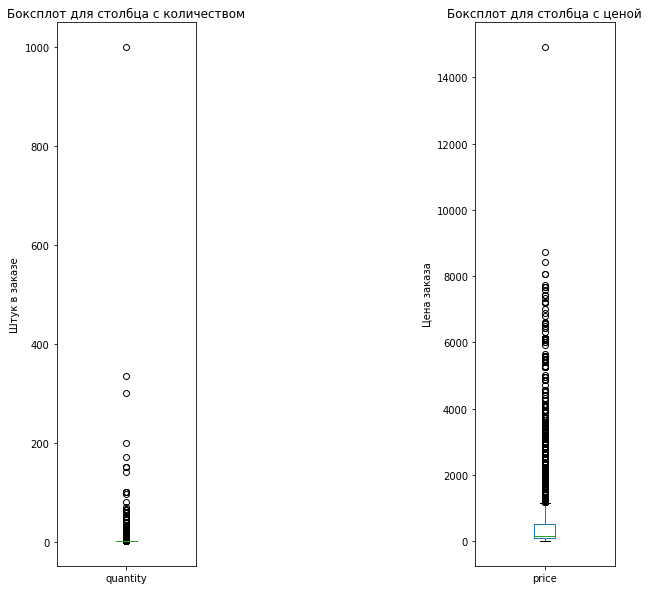

In [14]:
plt.figure(figsize=(10,10)) # Поле для отрисовки графиков
plt.subplot(1,2,1) # 2 ячейки под графики в одной строчке, выбираем первую ячейку

plt.subplots_adjust(wspace=2) # расстояние между графиками по вертикали

data['quantity'].plot(kind='box') # рисуем боксплот по quantity
plt.title('Боксплот для столбца с количеством') # подпись графика
plt.ylabel('Штук в заказе') # подпись оси Y

plt.subplot(1,2,2) # выбираем вторую ячейку
data['price'].plot(kind='box') # рисуем боксплот по price
plt.title('Боксплот для столбца с ценой') # подпись графика
plt.ylabel('Цена заказа') # подпись оси Y

plt.show() # показываем, что нарисовали

<h4><span style="color:#455a64;">Выбросы количества единиц</span></h4>

<p><span style="color:#455a64;">Рассмотрим топ-10 товаров по количеству в одном заказе:</span></p>

In [19]:
data.sort_values(by='quantity', ascending=False).head(10)

,date,customer_id,order_id,product,quantity,price
5456,2019-06-18,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"Вантуз с деревянной ручкой d14 см красный, Burstenmann, 0522/0000",1000,675.0
5071,2019-06-11,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,Вешалки мягкие для деликатных вещей 3 шт шоколад,334,148.0
3961,2019-05-20,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,Муляж ЯБЛОКО 9 см красное,300,51.0
1158,2018-12-10,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"Ручка-скоба РС-100 белая *Трибатрон*, 1108035",200,29.0
568,2018-11-01,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,Муляж ЯБЛОКО 9 см красное,170,51.0
212,2018-10-11,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,"Пружина дверная 240 мм оцинкованная (Д-19 мм) без крепления, 1107014",150,38.0
211,2018-10-11,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,"Крепеж для пружины дверной, 1107055",150,19.0
2431,2019-03-23,685d3d84-aebb-485b-8e59-344b3df8b3d3,70841,Плечики пластмассовые Размер 52 - 54 Тула 1205158,150,20.0
586,2018-11-02,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,Муляж ЯБЛОКО 9 см красное,140,59.0
1555,2019-01-21,8eabcaca-e8c8-4eee-9079-4ff5f612273a,69893,Щетка для мытья посуды КОЛИБРИ М5202 большая,100,34.0


<p><span style="color:#455a64;">Самым подозрительным выглядит только первая строчка. Её мы удаляем, остальные оставляем.</span></p>

In [20]:
# удаляем строчку со значением 1000 в столбце 'quantity'
data.drop(data[data['quantity']==1000].index, axis=0, inplace=True)

<div class="alert alert-success">
  
  <b>Комментарий тимлида v.2</b>
    
  ✔️ 1000 вантузов явный выброс.
 
</div>

<h4><span style="color:#455a64;">Выбросы цены за единицу товара</span></h4>

<p><span style="color:#455a64;">Теперь рассмотрим подозрительно высокие стоимости товаров:</span></p>

In [21]:
MAX_PRICE = 6000

abnormal_price = data.query('price > @MAX_PRICE').sort_values(by='price',ascending=False)
print(f'\t\t Товары с ценой, превышающей {MAX_PRICE}. Потенциальные аномалии в данных:') # просто для красоты
display(abnormal_price) # показываем, что нашлось

del abnormal_price, MAX_PRICE # удаляем ненужные более данные

		 Товары с ценой, превышающей 6000. Потенциальные аномалии в данных:


,date,customer_id,order_id,product,quantity,price
5992,2019-07-29,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,Сушилка уличная Leifheit 85210 LINOMATIC V 400 40 м 175х237х237 см зеленая,1,14917.0
2697,2019-04-05,c0c60544-3a99-49d0-8a8e-cf7f293c22cb,71035,"Сумка-тележка хозяйственная Andersen Royal Shopper, Hera, синяя 166-004-90",1,8737.0
1981,2019-02-24,ac250053-a236-467a-97d2-ddbb9bf4a1ba,70423,"Сумка-тележка хозяйственная Andersen Alu Star Shopper, Hava, синяя 115-103-90",1,8437.0
7436,2020-01-26,04416514-5346-4f90-93e3-fb7365e2ee8c,109758,Сумка-тележка хозяйственная Rolser MNB019 rojo LOGIC DOS+2 красная,1,8077.0
2997,2019-04-21,19d904d8-8d16-476d-8f66-b2a3b7a23660,71227,Сумка-тележка хозяйственная Rolser MNB019 rojo LOGIC DOS+2 красная,1,8077.0
6629,2019-10-16,d5584388-ffbe-42fd-a746-a98828ec919f,72992,Стремянка 7 ступенчатая Hailo 8040-707 XXL 13 см алюминиевая с лотком для инструментов,1,7724.0
2339,2019-03-14,27d4ce42-352b-4756-bf5b-8724e05d5131,70740,Сумка-тележка хозяйственная Rolser IMX006 bassi Logic Tour бордовая,1,7679.0
7190,2019-12-31,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,107812,Сумка-тележка хозяйственная Rolser IMX006 bassi Logic Tour бордовая,2,7679.0
5994,2019-07-30,e2fe6b48-1955-4882-925c-733f545df026,72140,Сумка-тележка хозяйственная Rolser MNB017 fucsia LOGIC DOS+2 фуксия,1,7679.0
654,2018-11-05,fc333417-1d11-4a2a-b946-0957ae0603e9,68872,Сумка-тележка хозяйственная Rolser MOU041 malva RD6 сиреневая,1,7597.0


<p><span style="color:#455a64;">Цены не выглядят аномальными. Даже самый дорогой товар, стоимостью в 14917, при проверке в поисковиках показывает стоимость в тех же пределах.<br>Итого, по колонке price считаем, что аномалий нет.</span></p>

<h4><span style="color:#455a64;">Пересечения данных</span></h4>

<p><span style="color:#455a64;">Попробуем найти мульти-заказы, т.е. существующие у нескольких пользователей</span></p>

In [22]:
(
    data
    .groupby('order_id').agg({'customer_id':'nunique'})
    .query('customer_id > 1')
    .sort_values(by='customer_id',ascending=False)
)

,customer_id
order_id,
72845,4
69485,3
71480,3
14872,2
70946,2
72790,2
72778,2
72188,2
71663,2


<p><span style="color:#455a64;">Нашлось 29 мульти-заказов, с количеством одновременного наличия у от 2 до 4х покупателей<br>Выборочно проверим содержимое этих заказов у разных пользователей:</span></p>

In [23]:
data.query('order_id == 69485 or order_id == 71054 or order_id == 69283')

,date,customer_id,order_id,product,quantity,price
1154,2018-12-10,2f955596-4b13-432e-93f3-6433395aafe6,69283,Сушилка для белья на батарею НИКА СБ6-65 двухъярусная,1,164.0
1160,2018-12-10,e3805ccd-2d64-4d0e-92dd-902293555c35,69283,Сушилка для белья на батарею НИКА СБ6-65 двухъярусная,1,164.0
1282,2018-12-20,5be0f4b4-947f-4672-b147-73ef5936ecd4,69485,Набор столовых приборов 24 предмета SAINT GERMAIN Domenik DM9638,1,1087.0
1292,2018-12-21,266beb08-ec9b-43b4-89bb-ac60fa23ffee,69485,Набор столовых приборов 24 предмета FARANDOLE Domenik DM9635,1,1274.0
1384,2018-12-26,e0461045-4fcc-4731-8837-509f6534512a,69485,Набор столовых приборов 24 предмета FARANDOLE Domenik DM9635,1,1274.0
2720,2019-04-07,d713f977-a28f-4c34-ae9a-d132068e64f3,71054,Вешалка-плечики без эссенции цвет тёмно-розовый FWM/L-Pink,10,43.0
4609,2019-06-05,34572907-a445-4b40-b1b6-fd0cbfa653b1,71054,Вешалка-плечики без эссенции цвет тёмно-розовый FWM/L-Pink,10,43.0


<p><span style="color:#455a64;">Удаляем такие дубликаты с полностью совпадающими колонками 'order_id', 'product', 'quantity' и 'price'</span></p>

In [24]:
data.drop(data[data.drop(['date','customer_id'], axis=1).duplicated()].index, inplace=True)

<p><span style="color:#455a64;">Повторяем проверку</span></p>

In [25]:
(
    data
    .groupby('order_id').agg({'customer_id':'nunique'})
    .query('customer_id > 1')
    .sort_values(by='customer_id',ascending=False)
)

,customer_id
order_id,
69485,2
70903,2


<p><span style="color:#455a64;">Выводим проблемные заказы</span></p>

In [26]:
data.query('order_id == 69485 or order_id == 70903')

,date,customer_id,order_id,product,quantity,price
1282,2018-12-20,5be0f4b4-947f-4672-b147-73ef5936ecd4,69485,Набор столовых приборов 24 предмета SAINT GERMAIN Domenik DM9638,1,1087.0
1292,2018-12-21,266beb08-ec9b-43b4-89bb-ac60fa23ffee,69485,Набор столовых приборов 24 предмета FARANDOLE Domenik DM9635,1,1274.0
2491,2019-03-28,5e5a3e1a-0388-4131-a770-f6e3b696985b,70903,Средство против засоров в системах водопровода DECS Антизасор 1000 мл Россия 4660015923303,1,104.0
3344,2019-05-01,718316fc-bdf3-4d1d-b8f1-a5c763238ff4,70903,Средство против засоров в системах водопровода DECS Антизасор 1000 мл Россия 4660015923303,1,142.0


<p><span style="color:#455a64;">В первом случае меняем номер 'order_id' добавив 1 справа, во втором случае, ищем аналогичный товар, смотрим цены. Если цена не меняется и равна одному из текущих значений, то отличающееся меняем, затем удаляем втрое появление этого 'order_id'</span></p>

In [27]:
data.loc[1292,'order_id'] = 694851

In [28]:
data.query('product.str.contains("засор",regex=True)')

,date,customer_id,order_id,product,quantity,price
2491,2019-03-28,5e5a3e1a-0388-4131-a770-f6e3b696985b,70903,Средство против засоров в системах водопровода DECS Антизасор 1000 мл Россия 4660015923303,1,104.0
3344,2019-05-01,718316fc-bdf3-4d1d-b8f1-a5c763238ff4,70903,Средство против засоров в системах водопровода DECS Антизасор 1000 мл Россия 4660015923303,1,142.0


<p><span style="color:#455a64;">К такому меня жизнь не готовила =)<br>
Удаляем второе появление. Это не должно сильно повлиять на результаты</span></p>

In [29]:
data.drop(3344, inplace=True)

<h3><span style="color:#455a64;">Новые колонки</span></h3>

<p><span style="color:#455a64;">Колонка 'date_ym' - год и месяц заказа</span></p>

In [30]:
data['date_ym'] = data['date'].dt.to_period('m') # вытащим из даты год и месяц

<p><span style="color:#455a64;">Добавим колонку с годом-месяцем первого заказа. Будем считать это датой регистрации</span></p>

In [31]:
# выделим для каждого пользователя время первого заказа. Будем считать это датой регистрации

data = data.merge(
                data.groupby('customer_id',as_index=False)['date_ym'].min().rename(columns={'date_ym':'reg_date'}),
                how='outer'
            )

<p><span style="color:#455a64;">Добавим колонку с категорией товара</span></p>

In [32]:
# словарь ключевых слов, по которым будем распределять товары по категориям.
# категория: (ключевое слово, вес слова)

categories = {
    'растения. букетные':[
                ('штук[а]? в упаковк',10),
                ('тюльп.*шт',10),
                ('калла',10),
            ],
    'растения. горшечные':[
                ('в горшке',6),
                ('диаметр горшка',6),
                ('кашпо',6),
                ('объем ([\d,]+) л',5),
                ('d[ -]?\d+ см',5),
                ('d12, h25-30',6),
                ('диам. ?\d+',4),
                ('пеларгония|бегония|зверобой|цикламен|кипарисовик',6),
                ('комнатное растение',6),
                
            ],
    'растения. черенки':[
                ('черенок',10),
                ('девичий виноград пятилисточковый',10),
                ('осина обыкн',8),
                ('ель канадская',8),
                ('новогоднее дерево',8),
            ],
    'растения. семена':[
                ('\d,\d+ г ',9),
                ('\d+ г ',9),
                ('томат.* № ?\d+',10),
                ('465\d{10}',10),
                ('4660010\d{5}',10), # семена

            ],
    'растения. рассада':[
                ('кассет',6),
                ('рассад',8),
                ('огур|арбуз|дыня|патиссон|тыква|клубника',9),
                ('вербейник',8),
                ('диам. ?\d+',3),
            ],
    'косметика и химия':
            [
                ('зубная',5),
                ('паста',5),
                (' гель ',10),
                ('462\d{10}',10), #химия|мыло
                ('4660015\d{5}',10), #химия DECS
                ('590086124',10), #химия Ludwig
                ('бальзам ',10),
                ('концентрат',10),
                ('антижир',8),
                ('кондиционер',4),
                ('отбеливатель',4),
                ('стиральный.*порошок',8),
                ('средство для мытья пола',10),
                (' ?мыло[ |-]',6),
                ('увлажняющая маска',8),
                ('крем ',5),
                ('чистя',3),
            ],
    'товары для кухни':[
              ('сковоро',4),
              ('крышк',3),
              ('антипригарн',5),
              ('тарелка|миска|блюдо',5),
              ('вилка',5),
              ('нож ',9),
              (' нож',4),
              ('терка ',3),
              (' нерж',2),
              ('стол',2),         
              ('ложк',5),
              ('котел|кастрю',4),
              ('круж[ка|ек]',10),
              ('фужер',4),
              ('бокал',4),
              ('стакан',4),
              ('кувшин',3),
              ('толкушк|мялка',4),
              ('чайн',4),
              ('противе',4),
              ('банк',3),
              ('лопатк',3),
              ('термос',4),
              ('luminar',4),
              ('емкость',4),
              ('посуд',3),
              ('мл',1),
              ('кухон',5),
              ('скатерть',5),
              ('половник',5),
              ('сахарница',5),
              ('сотейник',5),
              ('comfortline',5),
              ('венчик',5),
              ('кисточка силиконовая',6),
              ('коврик',2),
              ('сушк',2),
              ('[контей|емкость].*свч',6),
              ('овощечистка',6),
              ('ножеточка',6),
              ('alpenkok',6),
             ],
    'интерьер':[('муляж',10),
                ('см',1),
                ('полиурет|пласт|полиэфир',3),
                ('ткане',3),
                ('искус',4),
                ('скатерть',4),
                ('ассортиме',2),
                ('искус[а-я]+ цвето',5),
                ('декор',4),
                ('этажерк',4),
                ('салфетка',5),
                ('на стол',5),
                ('коврик',4),
                (' интерьер',4),
                (' придвер',4),
                ('обувница',4),
                ],
    'текстиль':[
                ('плед|одеяло',3),
                ('халат',4),
                ('полотенц|салфетк',5),
                ('покрывало',5),
                ('хлоп[ко]',3),
                (' бель',2),
                ('постель',3),
                (' 463000',5),# Wellness текстиль
                (' 46906590',5),# Wellness текстиль
                ('[одно|дву]спа',5),
                ],
    'быт':[
           (' 140\d{4}',10), #емкости 
           (' 1303007',9), # корыто
           (' 13010',9),  # корыто/ванна
           ('решетка вент',5),
           ('сетка для глаже',5),
           ('сменный блок',5),
           (' бель',4),
           ('пласт|силикон|полимер|латекс|эмалир|пвх',2),
           ('чехол',4),
           ('гладильн',5),
           ('вешал',5),
           ('суш',3),
           ('настенн',4),
           ('сумка',5),
           ('корзина',5),
           ('крюч',4),
           ('одежд',3),
           ('доска',3),
           ('щетка',4),
           ('сов[ок|ком]',4),
           ('швабр',4),
           ('ведр[а|о]',3),
           ('ручк',2),
           ('подстав',4),
           ('туале',4),
           ('унита|вантуз',4),
           ('прищеп',3),
           ('мыл',3),
           ('мусор',3),
           ('контейн',3),
           ('тележ',4),    
           ('флис',2),
           ('коврик',3),
           ('перчатк',4),
           ('обув',3),
           ('см',1),
           ('штор',2),
           ('болт',4),
           ('пружин',4),
           ('гараж',4),
           ('хранен',3),
           ('чистящ',4),
           (' ванн',3),
           ('складн',3),
           ('паст',3),
           ('губка',3),
           ('навесн',3),
           ('веник',3),
           ('бензи',3),
           ('фал',3),
           ('тряпк|салфет|ткань',3),
           ('мыть|антиж',3),
           ('пресс',3),
           ('комод',4),
           ('ведро|таз',4),
           ('увлажн',2),
           ('curver',1),
           ('зажигалка',2),
           ('электрич',2),
           ('шпагат|шнур',2),
           ('накип',2),
           ('скребок',2),
           ('соковыжималка',2),
           ('отбеливат',2),
           ('отделител',2),
           ('фиксатор',2),
           ('форма',2),
           ('хлебниц',2),
           ('ящик',2),
           ('[о,е]варка',5),
           ('орехок|чистка',3),
           ('светильни',3),
           ('механич',4),
           ('подголов',3),
           ('просеиват',3),
           ('[е|ё]рш',3),
           ('искус',2),
           ('webber',1),
           ('скатерт',4),
           ('подмет',8),
           ('мешок для деликатной стирки',6),
           ('плечики',4),
           ('урна',6),
           ('eurohouse',6),
           ('жестяная банка',3),
           ('короб ',4),
          ],
    'инструмент':[
           ('свер',2),
           ('сварк',3),
           ('петля',5),
           ('инструмент',3),
           ('измерительный.*угольник',8),
           ('линейка',8),
           ('штангенцир',8),
           ('насадка на валик',8),
           ('термометр',8),
           ('паста для полировки ',10),
           ('лестница',4),
           ('стремянк[а|и]',4),
           ('напильник',5),
           ('алюми',3),
    ],
    'техника':[
           ('( |\d)вт ',5),
           ('электрон',4),
           ('электроштопор',5),
    ]
}

In [33]:
# функция определения категории товара

def make_category(string_for_analysis, category_dict=categories, debug=0): # передаем словарь категорий, debug для точной настройки весов слов
    
    result = ('None',0) # список для хранения текущей категории и количества совпадений слов
    for cat in categories.keys(): # для каждого ключа в словаре категорий
        goal = 0 # обнуляем количество совпадений
        for tag, weight in category_dict[cat]: # для каждого значения признанка в категории
            if re.search(tag, string_for_analysis.lower()): # пытаемся найти совпадение в переданной строке
                if debug: # если режим дебага
                    print(cat, tag, weight) # вывести "сыгравшие" категории, слова и их веса 
                goal += weight # если находится - плюсуем счетчик
        if goal > result[1]: # если получившаяся сумма совпадений больше, чем текущая или ранее полученная
            result = (cat,goal) # переписываем список
    return result[0] # возвращаем категорию

In [34]:
data['category'] = data['product'].apply(make_category) # добавляем столбец с категорией товара

In [35]:
# если категория определяется неверно, есть возможность во-первых, почему это происходит, 
# во-вторых, исправить это, добавив новые ключевые слова или изменив вес у существующих

make_category('Таз пластмассовый 21,0 л круглый "Водолей" С614, 1404056', debug=1)

интерьер полиурет|пласт|полиэфир 3
быт  140\d{4} 10
быт пласт|силикон|полимер|латекс|эмалир|пвх 2
быт ведро|таз 4


'быт'

In [36]:
data.reset_index(inplace=True,) # сбросим индексы в датефрейме
del data['index']

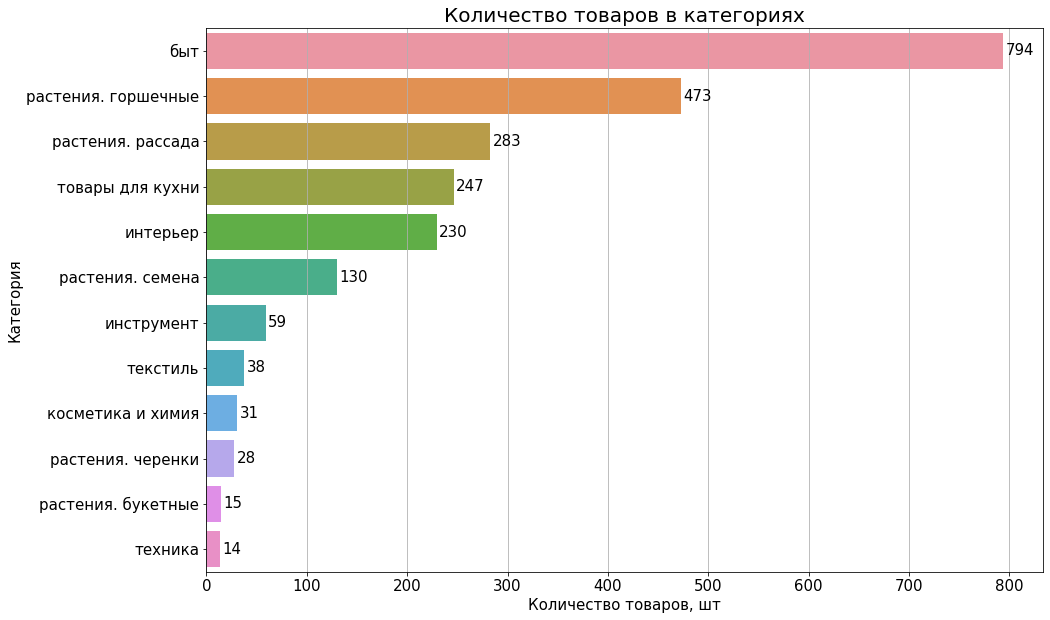

In [37]:
prod_in_cat = data.groupby('category',as_index=False).agg({'product':'nunique'}).sort_values(by='product', ascending=False)

plt.figure(figsize=(15,10))
ax = sns.barplot(data=prod_in_cat, x='product', y='category',orient='h')
plt.title('Количество товаров в категориях', fontsize=20)
plt.xlabel('Количество товаров, шт', fontsize=15)
plt.ylabel('Категория', fontsize=15)
for pos, value in enumerate(prod_in_cat['product']):
    plt.text(value+2,pos+0.1,value, size=15)
ax.tick_params(axis='both', labelsize=15)
plt.grid(axis='x')
plt.show()

del prod_in_cat

<h3><span style="color:#455a64;">Итог предобработки</span></h3>

<p><span style="color:#455a64;">Посмотрим, что получилось в итоге преобразований</span></p>

In [38]:
display(data.head(10))

,date,customer_id,order_id,product,quantity,price,date_ym,reg_date,category
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,2018-10,2018-10,растения. горшечные
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12, h25",1,194.0,2018-10,2018-10,растения. горшечные
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,2018-10,2018-10,растения. горшечные
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,2018-10,2018-10,растения. горшечные
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,2018-10,2018-10,растения. горшечные
5,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Шеффлера Лузеана d-9 см,1,164.0,2018-10,2018-10,растения. горшечные
6,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Юкка нитчатая d-12 см h-25-35 см,1,134.0,2018-10,2018-10,растения. горшечные
7,2018-10-01,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0,2018-10,2018-10,быт
8,2018-10-01,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С614, 1404056",1,269.0,2018-10,2018-10,быт
9,2019-10-31,6644e5b4-9934-4863-9778-aaa125207701,111409,"Рассада Дыни сорт Казачка, горшок 9*9см",1,38.0,2019-10,2018-10,растения. рассада


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5575 entries, 0 to 5574
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5575 non-null   datetime64[ns]
 1   customer_id  5575 non-null   object        
 2   order_id     5575 non-null   int64         
 3   product      5575 non-null   object        
 4   quantity     5575 non-null   int64         
 5   price        5575 non-null   float64       
 6   date_ym      5575 non-null   period[M]     
 7   reg_date     5575 non-null   period[M]     
 8   category     5575 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3), period[M](2)
memory usage: 392.1+ KB


In [40]:
# количество строк
print('Количество строк в датафрейме',len(data))

# количество уникальных покупателей
print('Количество уникальных покупателей',data['customer_id'].nunique())

# количество уникальных товаров
print('Количество уникальных товаров',data['product'].nunique())

# период времени, охватываемый данными
print('Минимальная дата в данных',data['date'].min())
print('Максимальная дата в данных',data['date'].max())

print(f'Во время EDA датафрейм уменьшился на {7474 - len(data)} строчку или на {round(100*(7474-len(data))/7474)}%')

Количество строк в датафрейме 5575
Количество уникальных покупателей 2430
Количество уникальных товаров 2342
Минимальная дата в данных 2018-10-01 00:00:00
Максимальная дата в данных 2020-01-31 00:00:00
Во время EDA датафрейм уменьшился на 1899 строчку или на 25%


<p><span style="color:#455a64;">В процессе обработки были проделаны следующие изменения:<br>- изменен тип данных для колонки с датами;<br>- удалены явные дубли в количестве 966 штук;<br>
    - удалены дубликаты без учета даты: 898 штук;<br>-  удалены строки, содержащие аномальные значения колонки с количеством товара;<br>- удалены дубли заказов у более, чем одного покупателя; <br>- были добавлены колонки с укороченной до месяца датой заказа;<br>- колонка с датой первого заказа для каждого покупателя, которую мы принимаем за дату регистрации;<br>- колонка с определенной по содержимому ячейки 'product' категорией.</span></p>

<h2><span style="color:#455a64;">Анализ данных</span></h2>

<h3><span style="color:#455a64;">Среднее количество заказанных товаров на одного покупателя</span></h3>

In [41]:
# функция категоризации количества заказов

def set_group_by_order_count(count_of_orders):
    if count_of_orders == 1 : return '1. 1 товар'
    if count_of_orders == 2 : return '2. 2 товара'
    if count_of_orders <= 10 : return '3. 3-10 товаров'
    if count_of_orders <= 50 : return '4. 11-50 товаров'
    if count_of_orders > 50 : return '5. более 51 товара'

In [42]:
# сборка датафрейма для графика

# группируем по покупателю и считаем количество заказанных позиций у каждого
mean = data.groupby('customer_id',as_index=False).agg({'quantity':'sum'})
mean_value = round(mean['quantity'].mean(),2)
max_order_count = mean['quantity'].max()
# добавляем значение группы, куда попадает каждый покупатель
mean['group'] = mean['quantity'].apply(set_group_by_order_count)
# собираем по группам и считаем какое количество в эти группы попало
mean = mean.groupby('group',as_index=False).agg({'quantity':'count'})
# переводим абсолютные показатели в проценты от общего числа заказов
mean['quantity'] = round(100*mean['quantity']/mean['quantity'].sum(),2)

In [43]:
# функция отрисовки горизонтального барплота по передаваемым параметрам

def make_barh(params):
    df = globals()[params['data']] # вытягиваем из словаря имя датафрейма
    plt.figure(figsize=(15,7)) # площадь отрисовки графика
    plt.title(params['title'],fontsize=15) # задаем название графика
    ax = sns.barplot(data=df, # непосредственно барплот по данным из переданного словаря
                x=params['x'],
                y=params['y'],
                orient='h')
    ax.tick_params(axis='both', labelsize=15)
    plt.xlabel(params['xlabel'], fontsize=15) # подпись оси X
    plt.ylabel(params['ylabel'],fontsize=15) # подпись оси Н
    plt.grid(axis='x') # отображаем сетку для X-оси
    x_max = 0 # задаем переменную для параметра xlim
    for pos, value in enumerate(df[params['x']]): # перебираем числовые  переменные, переданные в функцию(значения оси X)
        plt.text(value+0.3,pos+0.05,f'{value} {params["unit"]}', size=15, alpha=0.7) # отображаем текст на графике со значением X
        if value > x_max: # ищем максимальное значение среди X-значений
            x_max = value
    plt.xlim(0,x_max+0.15*x_max) # ставим лимит по X как X+15%X, чтобы подпись бара помещалась
    
    plt.show() # отображаем барплот

In [44]:
# словарь параметров для отрисовки горизонтального барплота
orders_params={
    'data':'mean', # имя датафрейма
    'x':'quantity', # имя столбца для значений оси X
    'y':'group', # имя столбца для значений оси Y
    'title':'Количество заказанных товаров на одного покупателя', # название графика
    'xlabel':'Покупателей,% от общего числа', # подпись оси X
    'ylabel':'Количество заказанных товаров', # подпись оси Y
    'unit':'%', # единицы измерения для подписей значений
}

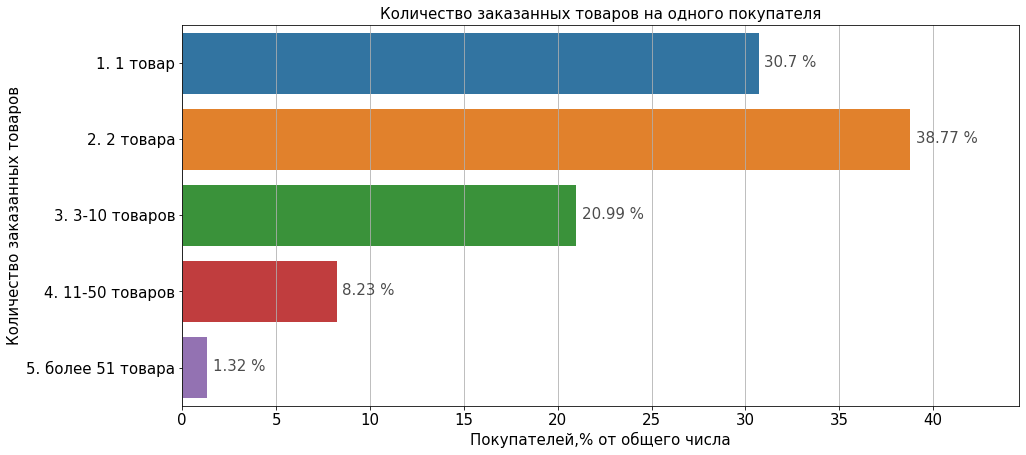

In [45]:
make_barh(orders_params)

In [46]:
print(f'Среднее количество заказанных товаров на одного покупателя: {mean_value}')
print(f'Максимальное число заказанных товаров на одного покупателя: {max_order_count}')

Среднее количество заказанных товаров на одного покупателя: 5.53
Максимальное число заказанных товаров на одного покупателя: 334


<p><span style="color:#455a64;">Среднее количество заказанных товаров на одного покупателя - 5,53. При этом максимальное количество заказанных товаров одним покупателем - 334.<br>Для полной картины рассмотрим график.<br>
График показывает распределение по количеству заказов среди покупателей и явно видно, что большинство(69%) покупают 1 или 2 товарые позиции за все время. От 3 до 10 товаров приобретают 21% покупателей, 11-50 товаров - чуть более 8% и более 51 товара было заказано 1,3% покупателей. Вероятнее всего, это оптовые клиенты.</span></p>

In [47]:
del mean, mean_value, max_order_count, orders_params # удаляем ненужные переменные

<h3><span style="color:#455a64;">Средняя сумма заказа</span></h3>

In [48]:
# функция категоризации общей суммы заказа

def set_group_by_total_cost(total_cost):
    if total_cost < 500 : return '1. менее 500 у.е.'
    if total_cost < 2000 : return '2. от 500 до 2000 у.е.'
    if total_cost < 5000 : return '3. от 2000 до 5000 у.е.'
    if total_cost > 5000 : return '4. более 5000 у.е.'

In [49]:
# создадим отдельный датафрейм, состоящий только из необходимых для анализа колонок:
# заказ, количество единиц товара в заказе, цена единицы товара
crop_data = data.loc[:,['order_id','quantity','price']]

# добавим столбец с полной суммой заказа = количество единиц товара в заказе * цена единицы товара
crop_data['total_cost'] = crop_data['quantity']*crop_data['price']

# группируем по номеру заказа и ситчаем общую сумму заказа
crop_data = crop_data.groupby('order_id',as_index=False).agg({'total_cost':'sum'})

# сохраним среднюю сумму заказа и максимальную
mean_cost = round(crop_data['total_cost'].mean(),2)
max_cost = crop_data['total_cost'].max()

# добавим поле с категорией по сумме заказа
crop_data['group'] = crop_data['total_cost'].apply(set_group_by_total_cost)

# собираем группы по категориям суммы заказа
crop_data = crop_data.groupby('group',as_index=False).agg({'order_id':'count'})

# переводим абсолютные значения в проценты от общего
crop_data['order_id'] = round(100*crop_data['order_id']/crop_data['order_id'].sum())

In [50]:
cost_param={
    'data':'crop_data',
    'x':'order_id',
    'y':'group',
    'title':'Сумма одного заказа',
    'xlabel':'Количество заказов, % от общего числа',
    'ylabel':'Сумма заказа',
    'unit':'%',
}

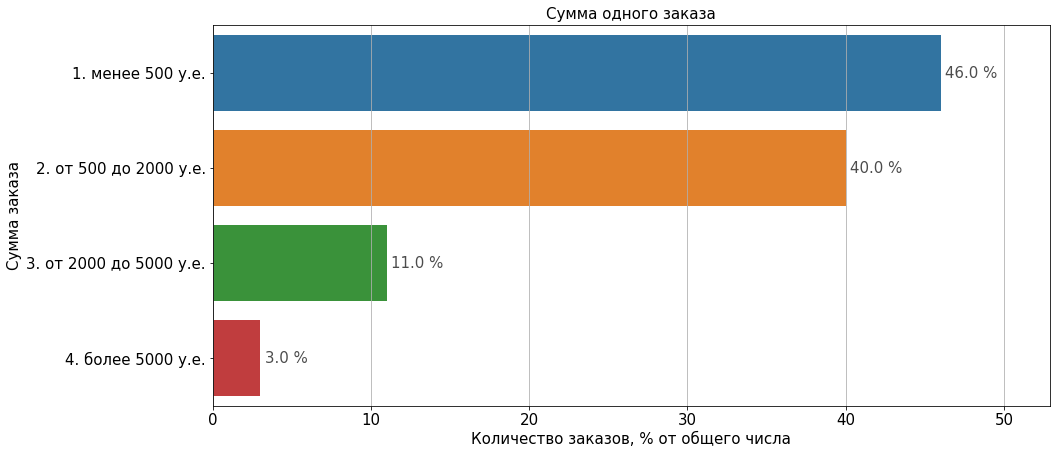

In [51]:
make_barh(cost_param)

In [52]:
print(f'Средняя сумма одного заказа: {mean_cost} у.е.')
print(f'Максимальное сумма заказа: {max_cost} у.е.')

Средняя сумма одного заказа: 1121.32 у.е.
Максимальное сумма заказа: 49432.0 у.е.


<p><span style="color:#455a64;">Средняя сумма заказа около 1121 у.е. Максимальная же - 49432 у.е.<br>
    По распределению сумм заказов видно,что 46% процентов всех заказов умещаются в сумму до 500 у.е., 40% - от 500 до 2000 у.е., относительно крупные заказы от 2000 до 5000 у.е. составляют 11%, и крупные заказы, более 5000 - около 3%.</span></p>

In [53]:
del crop_data, mean_cost, max_cost, cost_param # удаляем ненужные переменные

<h3><span style="color:#455a64;">Средняя стоимость товаров в зависимости от категории товара</span></h3>

In [54]:
# создадим отдельный датафрейм, состоящий только из необходимых для анализа колонок:
# цена и категория товара
crop_data = data.loc[:,['price','category']]
# группируем по категории и считаем среднюю цену
crop_data = (crop_data
             .groupby('category', as_index=False)
             .agg({'price':'mean'})
             .sort_values(by='price',ascending=False))
# округляем среднюю цену до 2х знаков после запятой
crop_data['price'] = round(crop_data['price'],2)

In [55]:
category_param={
    'data':'crop_data',
    'x':'price',
    'y':'category',
    'title':'Средняя стоимость товаров по категориям',
    'xlabel':'Стоимость, у.е.',
    'ylabel':'Категория',
    'unit':'у.е.',
}

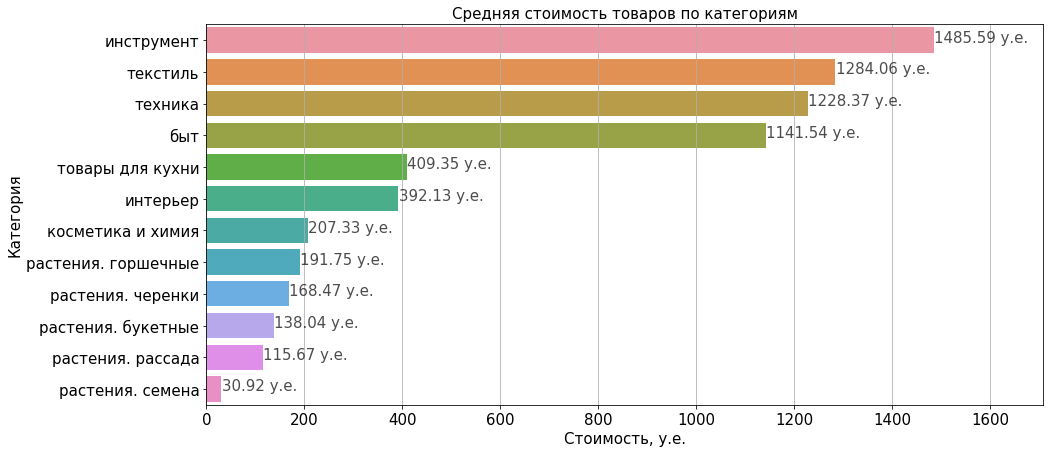

In [56]:
make_barh(category_param)

<p><span style="color:#455a64;">Распределение цен по категориям вполне предсказуемое: инструменты, текстильные изделия, техника и бытовые товары показывают максимальные средние цены. Семена, рассада и цветы для букетов - самые малоценные позиции.</span></p>

In [57]:
del crop_data, category_param

<h3><span style="color:#455a64;">Наиболее продаваемые категории товаров</span></h3>

In [58]:
# создадим отдельный датафрейм, состоящий только из необходимых для анализа колонок:
# количество проданного товара и его категория
crop_data = data.loc[:,['quantity','category']]
# группируем по категории и считаем сумму единиц проданного товара
crop_data = (crop_data
             .groupby('category', as_index=False)
             .agg({'quantity':'sum'})
             .sort_values(by='quantity',ascending=False))
# переводим абсолютное значение проданных товаров в процент от всех проданных товаров
crop_data['quantity'] = round(100*crop_data['quantity']/crop_data['quantity'].sum(),2)

In [59]:
category_param={
    'data':'crop_data',
    'x':'quantity',
    'y':'category',
    'title':'Доли категорий продаваемых товаров',
    'xlabel':'Доля, % от общего числа продаж',
    'ylabel':'Категория',
    'unit':'%',
}

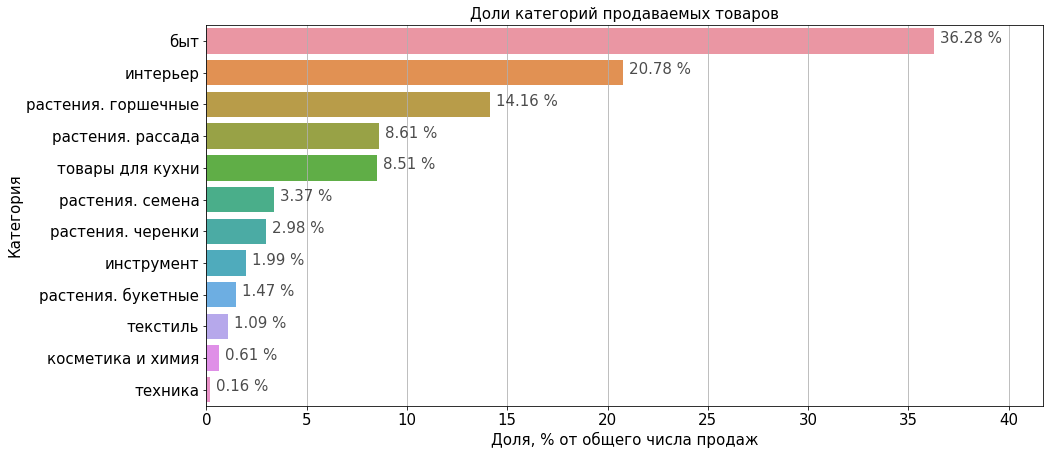

In [60]:
make_barh(category_param)

<p><span style="color:#455a64;">По данному графику можно сделать вывод, что основная продаваемая категория товаров, которая и делает, скорее всего, выручку магазина - бытовые принадлежности. В эту пользу говорит и то, что она, как было выяснено выше, входит в топ категорий по средней цене товаров. Вещи для интерьера и домашние, горшечные растения так же входят в самые популярные, продаваемые товары нашего магазина.<br>Чтобы это проверить, сделаем еще одну визаулизацию, которой не было в декомпозиции, но она напрашивается сейчас.</span></p>

<h3><span style="color:#455a64;">Распределение категорий товаров в общей выручке магазина
    </span></h3>

In [61]:
profit_category = data.loc[:,['quantity','price','category']]
profit_category['total_cost'] = profit_category['quantity']*profit_category['price']
profit_category = (profit_category
                   .groupby('category',as_index=False)
                   .agg({'total_cost':'sum'})
                   .sort_values(by='total_cost',ascending=False))
profit_category['total_cost'] = round(100 * profit_category['total_cost']/profit_category['total_cost'].sum(), 2)

In [62]:
category_param={
    'data':'profit_category',
    'x':'total_cost',
    'y':'category',
    'title':'Распределение категорий товаров в выручке магазина',
    'xlabel':'Доля выручки, % от общего',
    'ylabel':'Категория',
    'unit':'%',
}

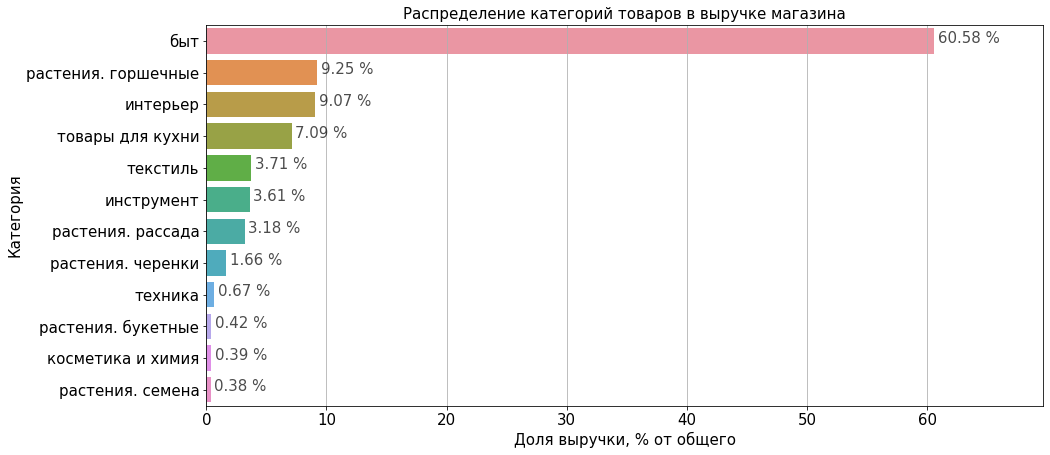

In [63]:
make_barh(category_param)

<p><span style="color:#455a64;">График с лихвой докаывает сделанное выше предположение, что бытовые товары - это основной источник оборота и дохода.</span></p>

<h3><span style="color:#455a64;">Наличие сезонности в продаже категорий товаров</span></h3>

<p><span style="color:#455a64;">Для начала посмотрим наличие сезонности по всем категориям товаров</span></p>

In [64]:
# функция отрисовки линейного графика по заданным параметрам

def make_line_graph(params):
    df = globals()[params['data']]
    ax = df.plot(figsize=(18,6))
    ax.tick_params(axis='both', labelsize=15)
    plt.title(params['title'],fontsize=15) # задаем название графика
    plt.xlabel(params['xlabel'], fontsize=15) # подпись оси X
    plt.ylabel(params['ylabel'],fontsize=15) # подпись оси Y
    plt.grid(True) # отображаем сетку 
    plt.show() # отображаем график

In [65]:
# нормализация занчений в интервал от 0 до 1

def normalize(x):
    x = (x - x.min()) / (x.max() - x.min())
    return x

In [66]:
# Добавим новый столбец с произведением количества единиц на цену
data['total_cost'] = data['quantity']*data['price']

In [67]:
# группируем пм месяцу-году, считая количество заказов и суммы всех заказов за месяц
sales_by_seasons = data.groupby('date_ym').agg({'order_id':'count','total_cost':'sum'})

# нормализуем значения числовых колонок, чтобы можно было их вывести на одном графике
sales_by_seasons['order_id']=normalize(sales_by_seasons['order_id'])
sales_by_seasons['total_cost']=normalize(sales_by_seasons['total_cost'])
# переименуем столбцы, чтобы на легенде этого не делать
sales_by_seasons.rename(columns={'order_id':'Количество заказов','total_cost':'Общая сумма заказов'},inplace=True)

In [68]:
param={
    'data':'sales_by_seasons',
    'title':'Динамика продаж по всем категориям за время наблюдения',
    'xlabel':'Дата',
    'ylabel':'Доля',
}

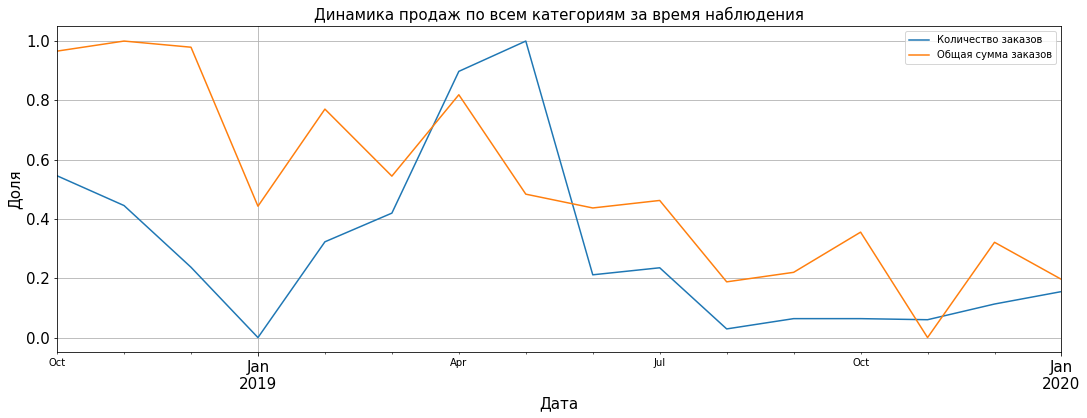

In [69]:
make_line_graph(param)

<p><span style="color:#455a64;">По общему графику найти сезонность продажи товара не получается. Но это в том числе и потому, что интервал представлен 1,5 годами, и попытаться обозначить сезонность можно только интервалу с октября по январь - тем месяцам, которые имеют данные по продажам за 2 года, но на графике нет похожести в эти месяцы.<br>Но график дает внезапную картину того, что суммы ежемесячных заказов катастрофически падают весь предоставленный отрезок времени. </span></p>

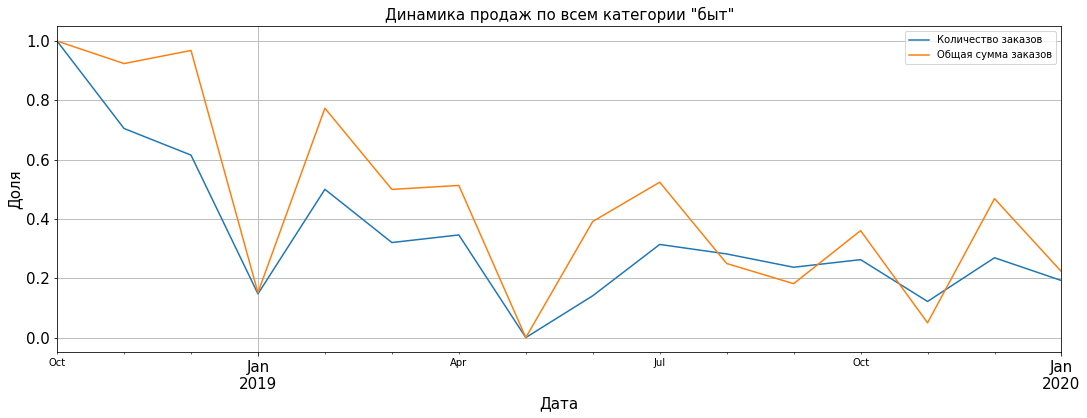

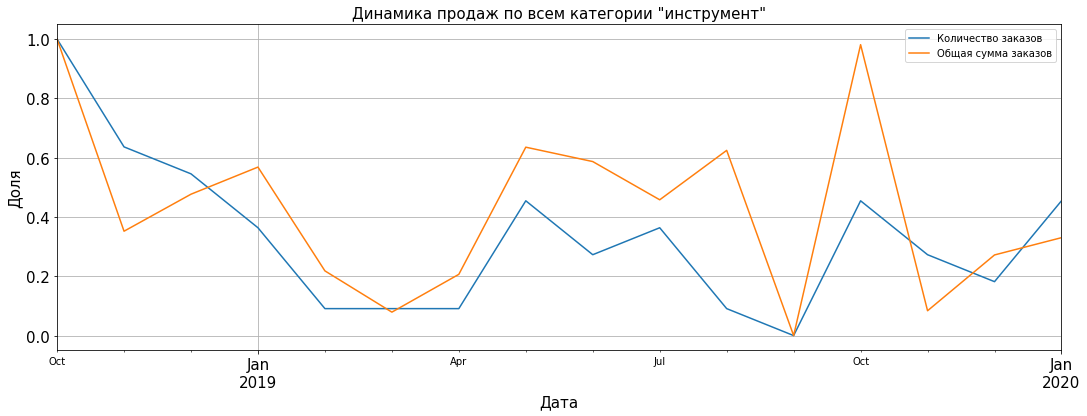

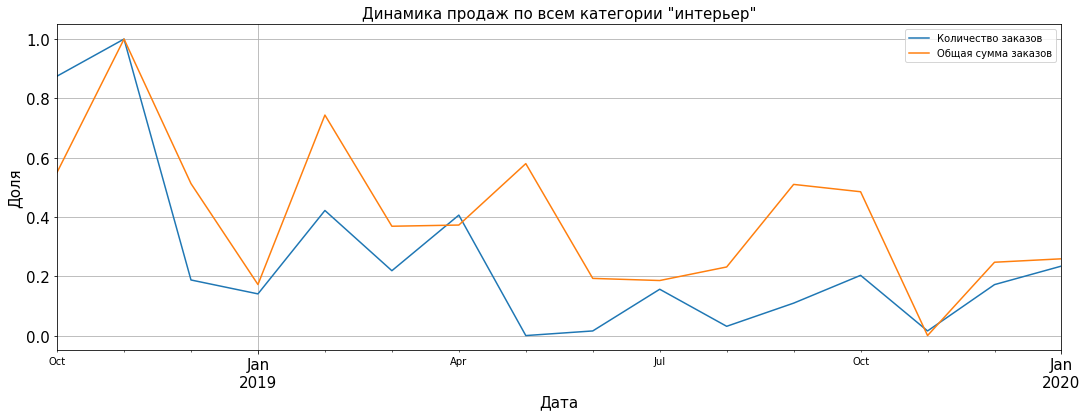

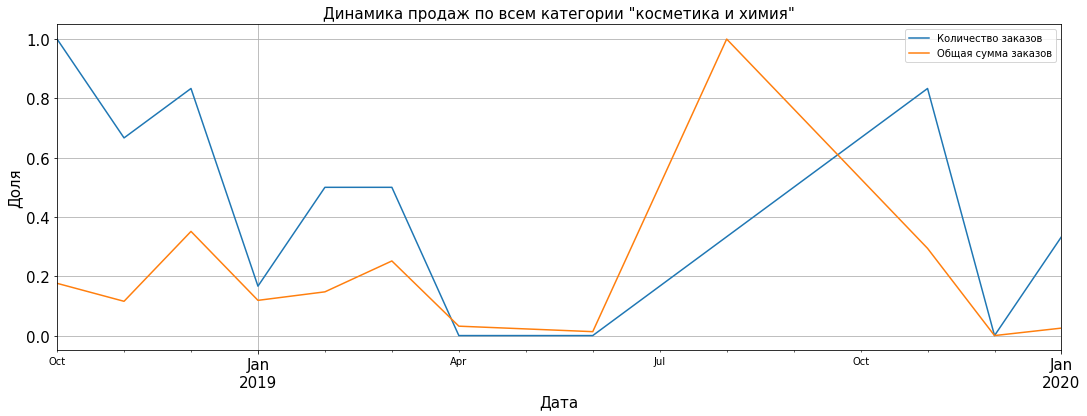

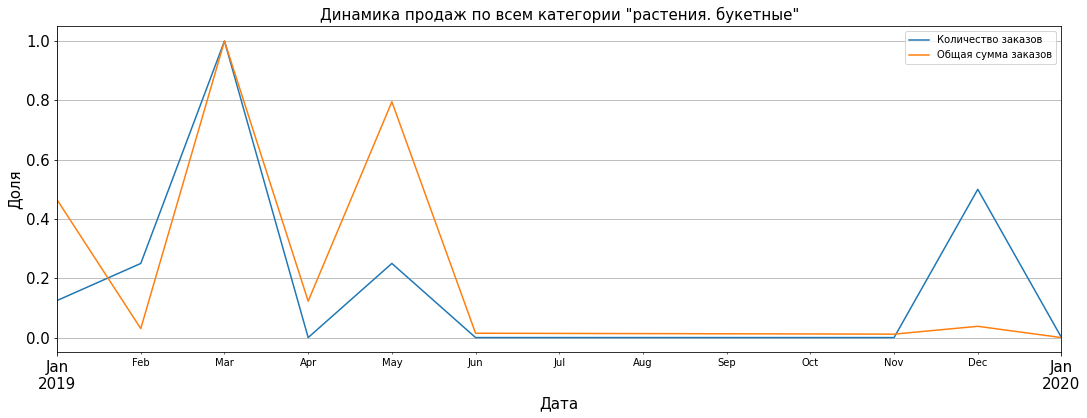

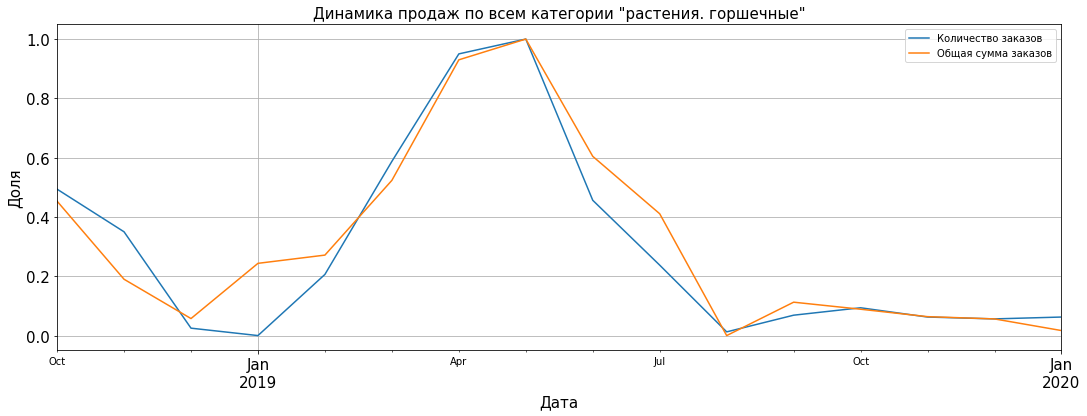

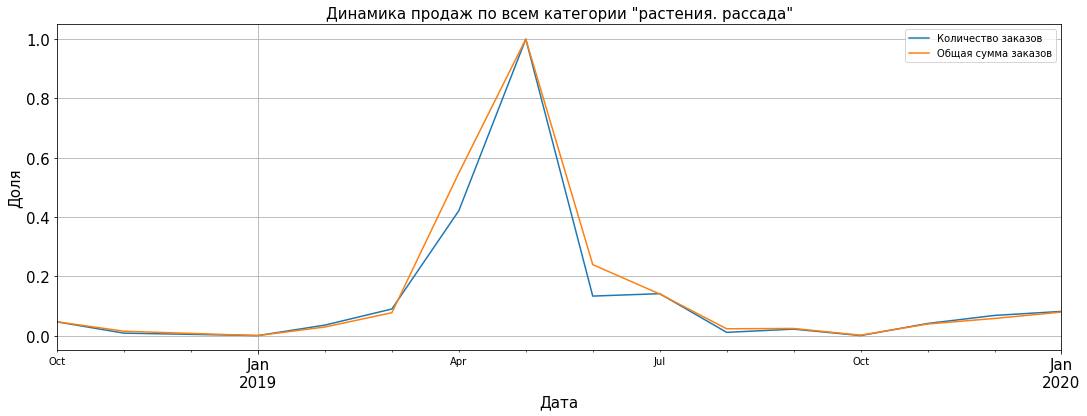

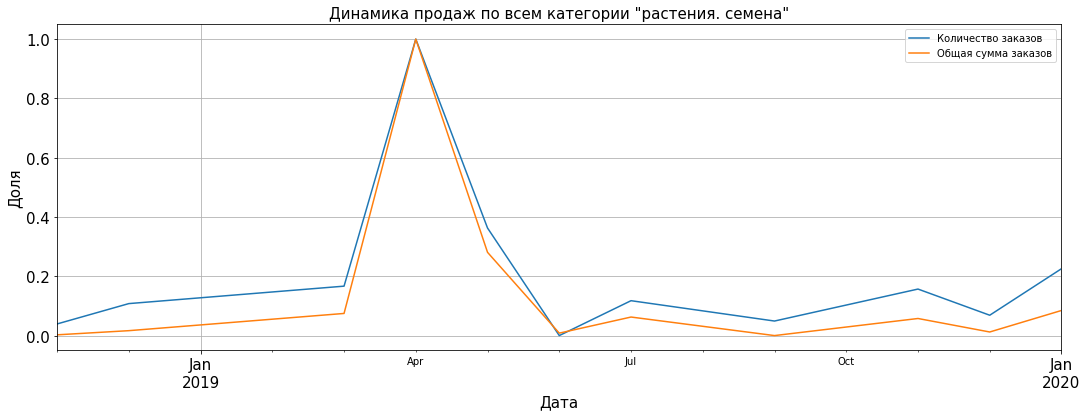

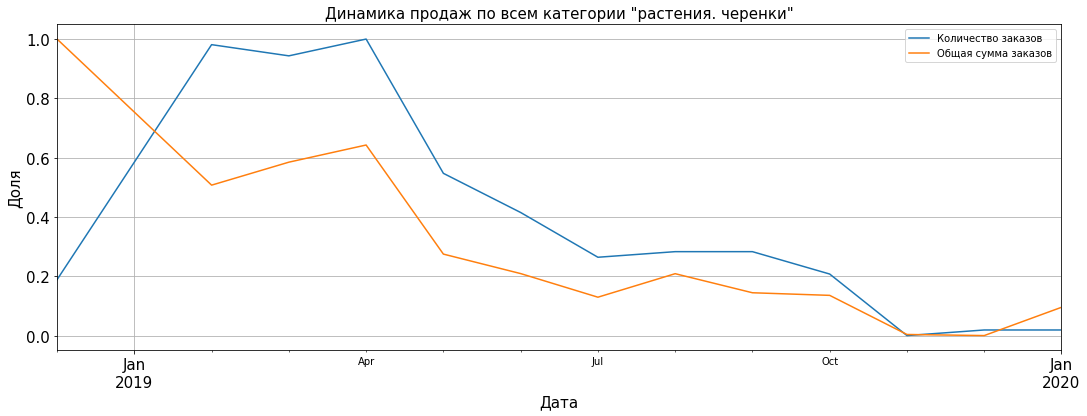

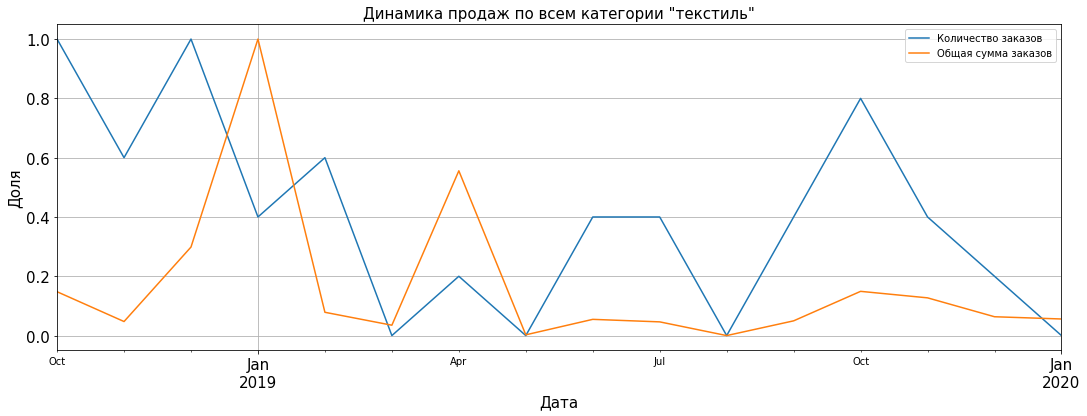

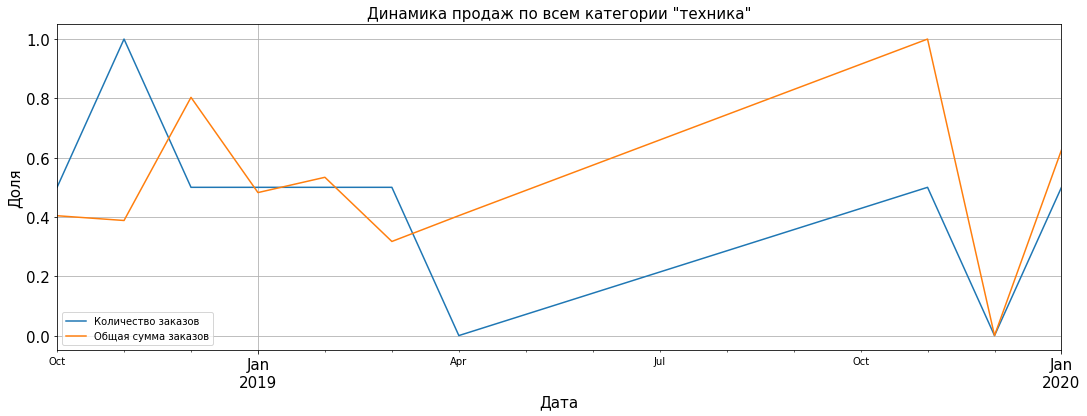

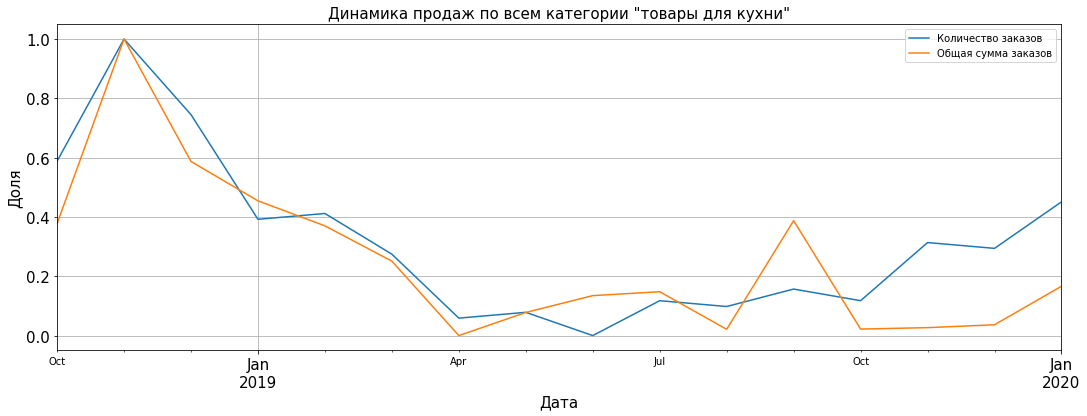

In [70]:
for category in sorted(data['category'].unique()):
    sales_by_category = (data
                         .query('category == @category')
                         .groupby('date_ym')
                         .agg({'order_id':'count','total_cost':'sum'}))
    sales_by_category['order_id']=normalize(sales_by_category['order_id'])
    sales_by_category['total_cost']=normalize(sales_by_category['total_cost'])
    sales_by_category.rename(columns={'order_id':'Количество заказов','total_cost':'Общая сумма заказов'},inplace=True)
    param={
            'data':'sales_by_category',
            'title':f'Динамика продаж по категории "{category}"',
            'xlabel':'Дата',
            'ylabel':'Доля',
         }
    make_line_graph(param)

In [71]:
del sales_by_seasons, sales_by_category, param # очищаем память

<p><span style="color:#455a64;"><b>Бытовые товары</b> Можно предположить повышение спроса на данную категорию товаров начиная с февраля и заканчивая апрелем, т.е. уборка дома после нового года, подготовка к летнему сезону и постоянные продажи в течение летних месяцев.Так же можно заметить, что падение ежемесячных сумм заказов сильно похоже на общий график, что еще раз говорит о том, что бытовые принадлежности - основной товар магазина.<br>
    <b>Инструменты</b> Предположить наличие сезонности у данной категории товаров я не могу. Они относительно стабильно продаются весь год.<br>
    <b>Интерьер</b> Как и инструменты, продаются более-менее стабильно на протяжении всего года. Что странно, т.к. есть праздники, такие как новый год или хеллоуин, которые подразумевают украшения дома и спрос на эту категорию товаров должен становиться высоким. На графике этого нет.<br>
<b>Косметика и химия</b> Совсем непонятное распределение. Особенно, отсутствие продаж с апреля по июнь. Возможно, не было в ассортименте?<br>
    <b>Растения. Букетные</b> Цветы для составления букетов. Тут предсказуемые пики в марте и мае, и, почему-то, в декабре. Новогодние букеты? Остальное время продажи практически нулевые<br>
    <b>Растения. Горшечные</b> Растения в горшках. Устойчивый спрос в летние месяцы. Как минимум, потому что в теплое время года хозяйки занимаются пересадкой, обновлением домашних зеленых насаждений. И трансфер живых цветов более успешен, когда на улице температура выше нуля.<br>
    <b>Растения. Рассада</b> Всё, как должно быть: начало дачного сезона, высадка в открытый грунт требует рассады. Спрос высокий, заказов много.<br>
    <b>Растения. Семена</b> Для тех, кто предпочитает собственную рассаду. Пик продаж смещен на -1 месяц от пика продажи рассады. Но и в течение года семена продаются стабильно.<br>
    <b>Растения. Черенки</b> Как и в целом по растениям, Пик приходится на весну, но в отличие от всех остальных представителей категории "Растения", довольно высок до заморозков.<br>
    <b>Текстиль</b> Не имеет ярко выраженных пиков. Сезонность так же не наблюдается.<br>
    <b>Техника</b>  Крайне странный график. Скорее всего связан с тем, что ассортимент этой категории низкий и даже единичная продажа будет показываться как пик.<br>
    <b>Товары для кухни</b> Есть спрос, когда люди проводят много времени дома. Т.е. холодные месяцы. Вероятнее всего, время проводимое на кухне за готовкой или за столом играет роль в наличии спроса на кухонную утварь.</span></p>

<hr>
<hr>

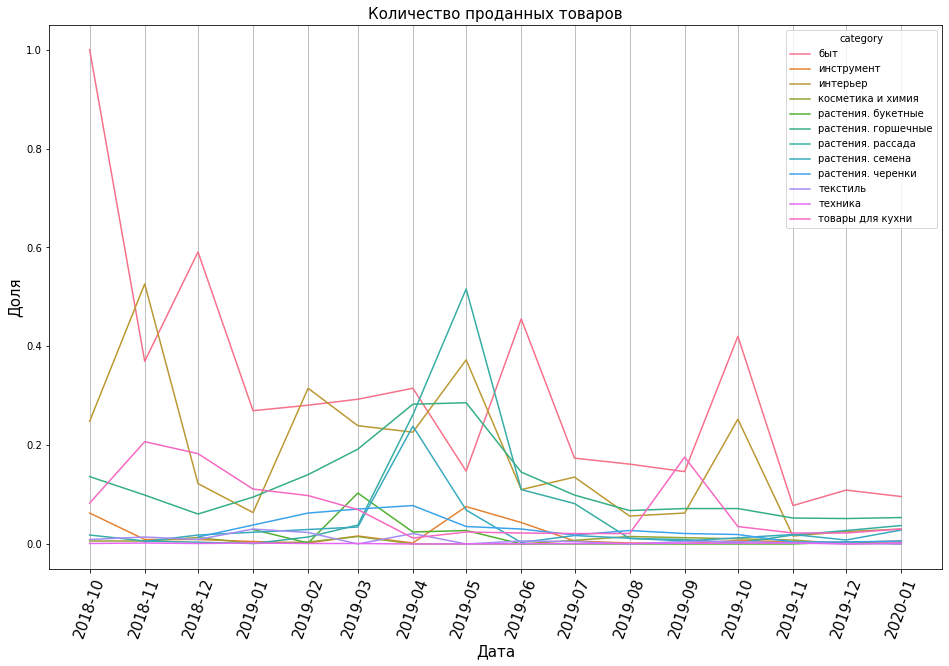

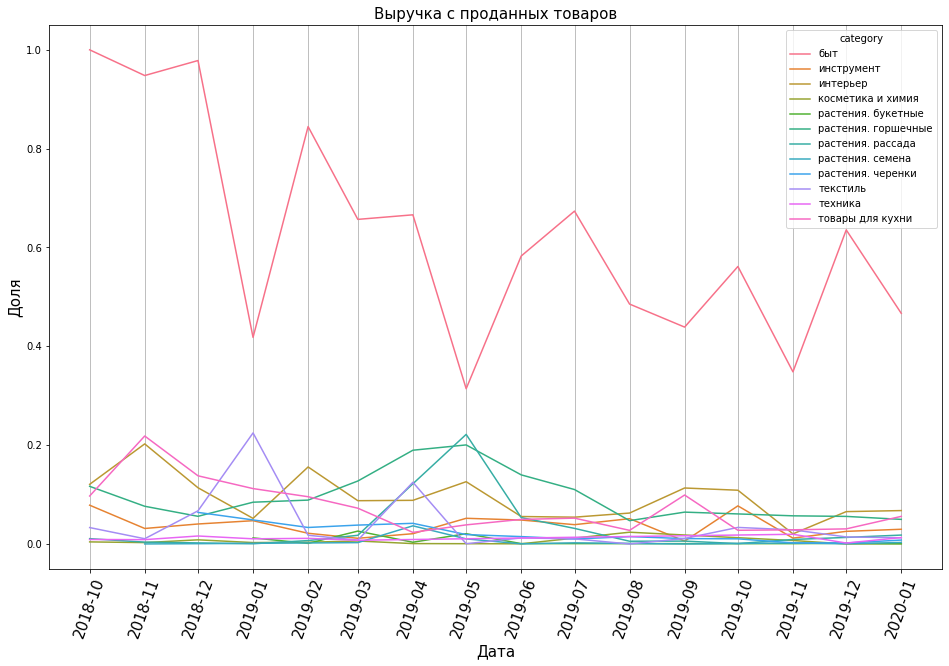

In [72]:
# графики количества проданных товаров и выручкек с их продажи

# собираем датафрейм с группировкой по категории и дате, суммируем количество проданных товаров и суммы продажи
sales_in_time = data.groupby(['category','date_ym'],as_index=False).agg({'quantity':'sum','total_cost':'sum'})
# нормализуем столбцы, чтобы можно было разместить на одном графике без особой потери точности
sales_in_time['quantity'] = normalize(sales_in_time['quantity'])
sales_in_time['total_cost'] = normalize(sales_in_time['total_cost'])
#####for category in data['category']:
#####    sales_in_time.loc[sales_in_time['category']==category,'quantity'] = normalize(sales_in_time.loc[sales_in_time['category']== category,'quantity'])
#####    sales_in_time.loc[sales_in_time['category']==category,'total_cost'] = normalize(sales_in_time.loc[sales_in_time['category']== category,'total_cost'])
# переводим тип Period в тип Dataframe
sales_in_time['date_ym'] = sales_in_time['date_ym'].astype('str')
sales_in_time['date_ym'] = pd.to_datetime(sales_in_time['date_ym'])

col_title = {'quantity':'Количество проданных товаров','total_cost':'Выручка с проданных товаров'} 
for col in col_title:
    plt.figure(figsize=(16,10))
    ax = sns.lineplot(data=sales_in_time,x='date_ym',y=col,hue='category')
    ax.xaxis.set_major_locator(MonthLocator(bymonthday=1))
    ax.tick_params(axis='x', labelsize=15)
    plt.xticks(rotation=70)
    plt.grid(axis='x')
    plt.title(col_title[col], size=15)
    plt.xlabel('Дата', size=15)
    plt.ylabel('Доля', size=15)
    plt.show()

del sales_in_time

<h3><span style="color:#455a64;">Итоги анализа данных</span></h3>

<p><span style="color:#455a64;">После анализа данных, мы можем говорить о том, что:</span></p>
<ol>
    <li><span style="color:#455a64;">Почти 90% покупателей совершают 1 или 2 заказа. При этом среднее количество заказов равно 2,29. Это является результатом того, что есть 2,5% покупателей (возможно, оптовые), &nbsp;имеющих более 11 заказов. Рекордом является число заказов, равное 143.</span></li>
    <li><span style="color:#455a64;">Средняя сумма одной покупки - 1105 у.е. Хотя 86% всех покупок укладываются в сумму до 2000 у.е. Максимальная покупка, зафиксированная в наблюдениях, 47 385 у.е.</span></li>
    <li><span style="color:#455a64;">Самая дорогая категория товаров, представленная в магазине - инструменты (средняя цена 1485 у.е.). Следующие 3 места: текстиль (1284 у.е.), техника (1215 у.е.) и бытовые товары (1142 у.е.). Минимальные цены показывают семена - 31 у.е.</span></li>
    <li><span style="color:#455a64;">Товары, пользующиеся спросом со стороны покупателей: бытовые товары (34%), интерьер(19%), растения горшечные (15,5%), рассада (9,5%) и товары для кухни (9,3%). Меньше всего интересны косметика и химия (0,67%) и техника (0.19%)</span></li>
    <li><span style="color:#455a64;">В подтверждение п.4 мы провели дополнительный анализ для выяснения, из продажи каких категорий товаров складывается выручка магазина. И да, лидеры у нас остались те же, но их доли существенно изменились: бытовые товары у нас приносят 60% выручки, горшечные растения - 9.4%, интерьерные товары - 8.6% и товары для кухни - 7,3%.</span></li>
    <li><span style="color:#455a64;">Выраженная сезонность в продаже товаров у нас наблюдается только среди растений: начиная с весны и заканчивая поздней осенью люди тянутся к земле, и чтобы это приносило не только удовольствие, но и пользу, занимаются выращиванием овощей, ягод и фруктов.</span><br><span style="color:#455a64;">Легкая предрасположенность к сезонности есть и у кухонных товаров. Но т.к. данные у нас затрагивают относительно небольшой период времени (16 месяцев), говорить об этом с уверенностью не приходится</span></li>
</ol>

<h2><span style="color:#455a64;">Сегментирование пользователей и проверка гипотез</span></h2>

<h3><span style="color:#455a64;">Сегментирование пользователей</span></h3>

<p><span style="color:#455a64;">Для использования метода KMeans необходима таблица средних значений для пользователей. Поэтому начнем с её составления.</span></p>

In [73]:
# собираем таблицу средних значений

#total_mean = (
#    data
#    .groupby('customer_id',as_index=False)
#    .agg({'order_id':'nunique',
#          'total_cost':'sum',
#          'quantity':'mean',
#          'product':'nunique'
#         })
#)
#total_mean['средний_чек_покупателя'] = total_mean['total_cost']/total_mean['order_id']
##total_mean['среднее_количество_позиций'] = total_mean['quantity']/total_mean['order_id']
#total_mean['среднее_количество_товаров_в_чеке'] = total_mean['product']/total_mean['order_id']
#total_mean['средняя_стоимость_товаров_в_чеке'] = total_mean['total_cost']/total_mean['quantity']
#total_mean.drop(['order_id','total_cost','quantity','product'], axis=1, inplace=True)
#
#display(total_mean.head(10))

In [74]:
# собираем таблицу средних значений

total_mean = (
data.groupby('customer_id', as_index=False).agg(
    количество_чеков = pd.NamedAgg(column='order_id',aggfunc='nunique'),
    среднее_количество_покупаемых_позиций = pd.NamedAgg(column='quantity',aggfunc='mean'),
    общая_сумма_чеков = pd.NamedAgg(column='total_cost',aggfunc='sum'),
    средняя_стоимость_покупаемых_товаров=pd.NamedAgg(column='price',aggfunc='mean'),
    )
)
total_mean['средний_чек'] = total_mean['общая_сумма_чеков']/total_mean['количество_чеков']
total_mean.drop('общая_сумма_чеков',axis=1,inplace=True)

total_mean.sort_values(by='количество_чеков').tail()

,customer_id,количество_чеков,среднее_количество_покупаемых_позиций,средняя_стоимость_покупаемых_товаров,средний_чек
17,0184f535-b60a-4914-a982-231e3f615206,5,1.933333,110.333333,1178.200000
1732,b7b865ab-0735-407f-8d0c-31f74d2806cc,7,3.777778,83.388889,539.857143
1089,73d1cd35-5e5f-4629-8cf2-3fda829d4e58,17,1.000000,1256.529412,1256.529412
733,4d93d3f6-8b24-403b-a74b-f5173e40d7db,35,6.866667,677.066667,1636.514286
1898,c971fb21-d54c-4134-938f-16b62ee86d3b,126,2.335664,932.846154,1265.936508


<p><span style="color:#455a64;">Проведя разбиение на кластеры в таком виде, у нас получался кластер, состоящий из одного покупателя. И несмотря на то, что покупки этого клиента выглядят как реальные, мы от него избавляемся, как от выброса данных.</span></p>

In [75]:
# удаляем из датафремов покупки подозрительного покупателя
total_mean.drop(total_mean.query('customer_id =="c971fb21-d54c-4134-938f-16b62ee86d3b"').index, inplace=True)
data.drop(data.query('customer_id =="c971fb21-d54c-4134-938f-16b62ee86d3b"').index, inplace=True)

In [78]:
scaler = StandardScaler() # объявляем объект стандартного масшабирования
# масштабируем средные значения без колонки 'customer_id'
total_mean_st = scaler.fit_transform(total_mean.drop('customer_id',axis=1))
# смотрим результат масшабирования
total_mean_st

array([[-0.4335521 , -0.1770379 , -0.56084666, -0.2938999 ],
       [-0.4335521 , -0.1770379 , -0.26479227, -0.34758197],
       [-0.4335521 , -0.10379392, -0.2501482 , -0.12335243],
       ...,
       [-0.4335521 , -0.1770379 , -0.31653467, -0.37276028],
       [-0.4335521 , -0.1770379 ,  0.25458426, -0.09484868],
       [-0.4335521 , -0.1770379 , -0.13299559, -0.28344852]])

<p><span style="color:#455a64;">Методом "локтя" определим оптимальное количество кластеров, которое будет использоваться в методе KMeans</span></p>

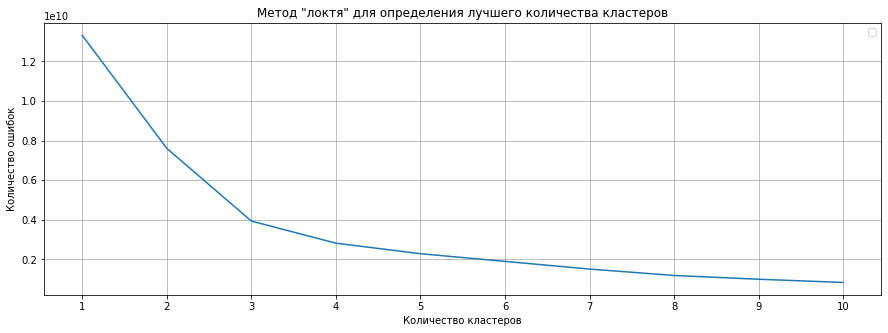

In [79]:
wcss = [] #  массив под сборку значений метрик ошибок при кластеризации
for i in range(1,11): # будем прогонять количество кластеров от 1 до 11
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0) # запускаем кластеризацию по i кластерам
    kmeans.fit(total_mean.drop('customer_id', axis=1))# обучаем модель
    wcss.append(kmeans.inertia_)# в массив добавляем значение инерции получившейся модели
    
# формируем датафрейм из числа кластеров и соотвествущего им набора инерций    
df = pd.DataFrame({'n_clus':range(1,11),'wcss':wcss})
df.set_index('n_clus', inplace=True)# столбец с кластерами назначаем индексом
ax = df.plot(figsize=(15,5))# рисуем график

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))# устанавливаем масштабирование меток оси X
plt.title('Метод "локтя" для определения лучшего количества кластеров')# подписываем график
plt.xlabel('Количество кластеров')
plt.ylabel('Количество ошибок')
plt.grid(True)# выводим сетку
plt.legend('')# скрываем легенду
plt.show()# показываем график

<p><span style="color:#455a64;">По графику, оптимальное количестово кластеров можно выбрать как 3, так и 4. Сильной разницы быть не должно. Самый сильный "излом" наблюдается в значении 3. Это потенциальное число кластеров. Проверим предположение на дендрограмме</span></p>

In [80]:
linked = linkage(total_mean_st, method = 'ward')

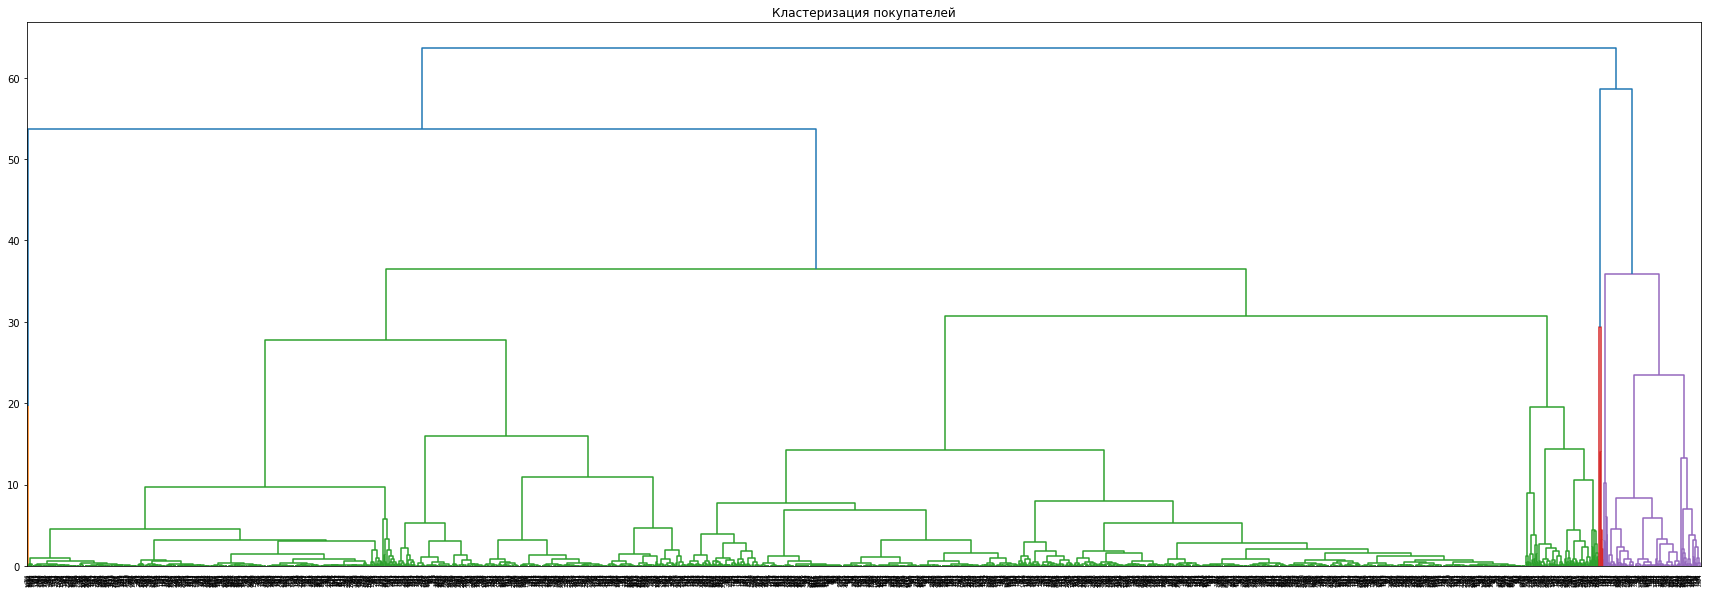

In [81]:
plt.figure(figsize=(30, 10))
dendrogram(linked, orientation='top')
plt.title('Кластеризация покупателей')
plt.show()

In [82]:
n_clusters = 3# задаем количество кластеров
km = KMeans(n_clusters=n_clusters, random_state=0) # задаем количество кластеров
labels = km.fit_predict(total_mean_st) # применяем алгоритм к стандартизированному массиву, получаем вектор меток кластеров
total_mean['cluster'] = labels # добавляем метки кластеров к таблице средних

In [83]:
print('Распределение покупателей по кластерам:')
total_mean.groupby('cluster').agg({'customer_id':'count'})

Распределение покупателей по кластерам:


,customer_id
cluster,
0,2224
1,197
2,8


<h4><span style="color:#455a64;">Средние значения признаков для кластеров</span></h4>

<p><span style="color:#455a64;">Распределение выглядит, на мой взгляд, реальным. Есть основная масса покупателей: у них потребительское поведение схоже, и есть группы пользователей с "особенностями".<br>Попробуем разобрать их:</span></p>

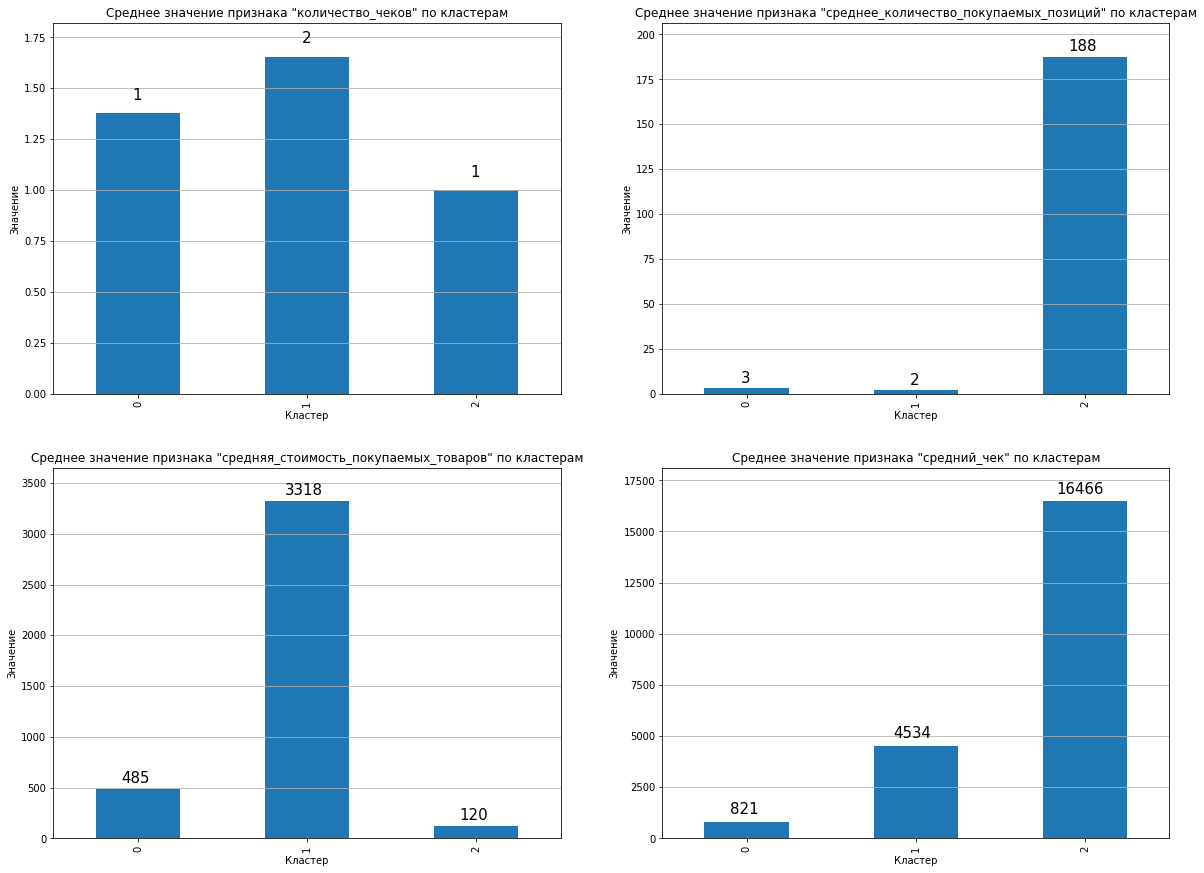

In [84]:
clusters = total_mean.groupby('cluster').mean() # группируем датафрейм средних по кластеру и получаем среднее средних
plt.figure(figsize=(20,15)) # поле для рисования
i = 1 # счетчик subplot
for col in clusters.columns: # для каджого столбца в датафрейме...
    plt.subplot(2,2,i) # назначаем i ячейку в сетке графиков 2х2
    clusters[col].plot(kind='bar') # ...рисуем бары по этому столбцу в разрезе кластеров
    plt.xlabel('Кластер') # подписи графиков
    plt.ylabel('Значение')
    plt.title(f'Среднее значение признака "{col}" по кластерам')
    plt.grid(axis='y')
    for pos, value in enumerate(clusters[col]):
        plt.text(pos-len(str(round(value)))/30,value+clusters[col].mean()*0.05,round(value), size=15)
    plt.ylim(0,clusters[col].max()+clusters[col].max()*0.1)
    i += 1 # увеличиваем счетчик ячейки
plt.show() # отображаем результат

<h4><span style="color:#455a64;">Распределение значений признаков для кластеров</span></h4>

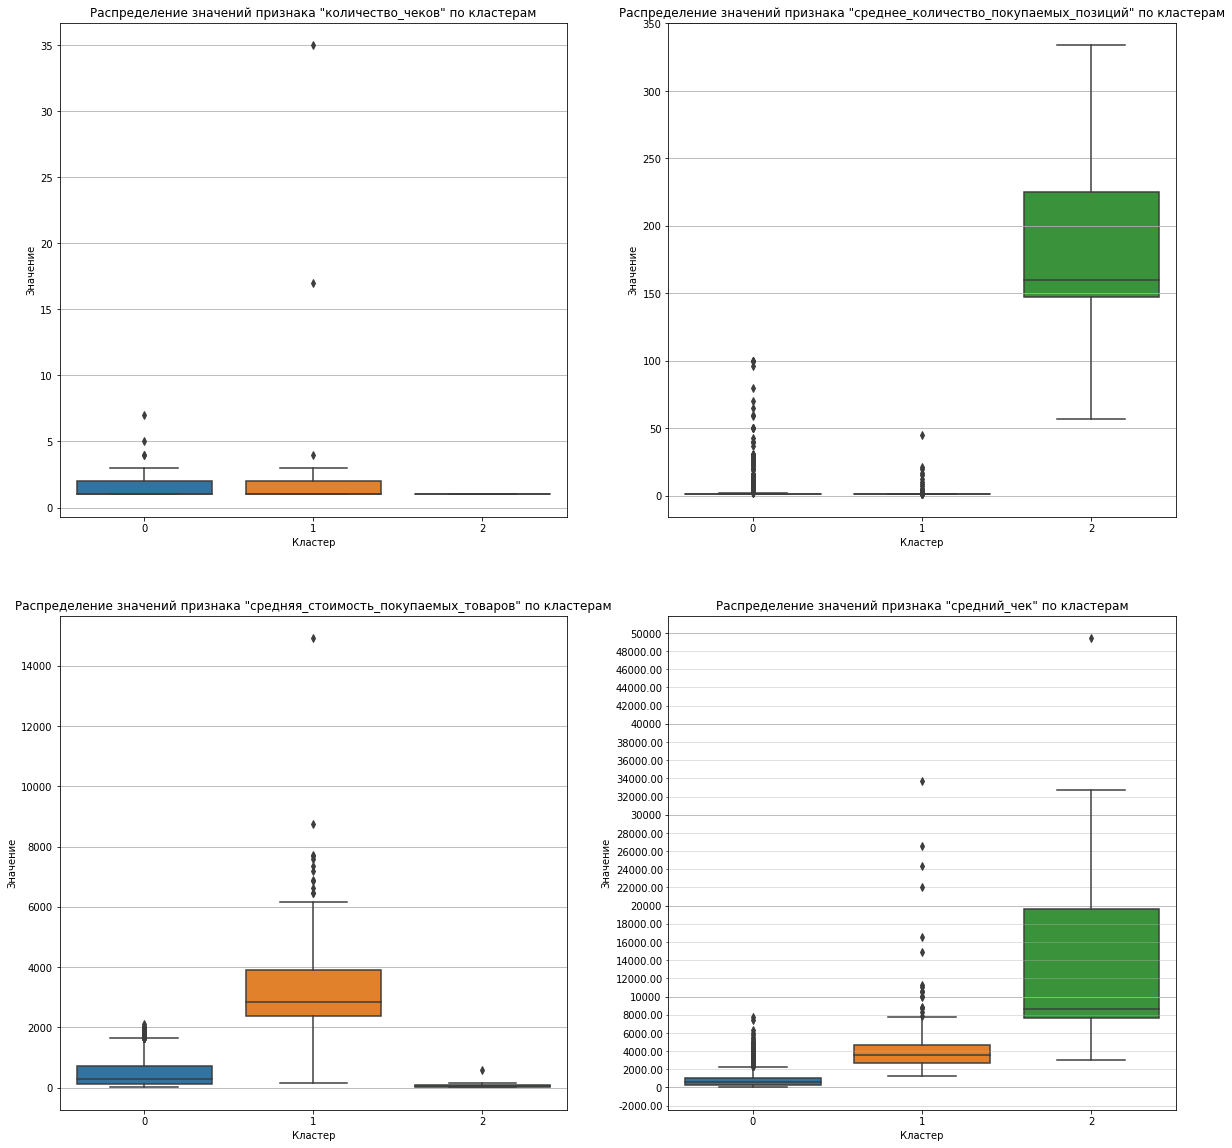

In [85]:
# процедура аналогична построению баров
# но строятся боксплоты

plt.figure(figsize=(20,20))
i = 1
for col in clusters.columns:
    plt.subplot(2,2,i)
    ax = sns.boxplot(data=total_mean, x='cluster', y=col)
    plt.xlabel('Кластер')
    plt.ylabel('Значение')
    plt.title(f'Распределение значений признака "{col}" по кластерам')
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(2000))
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.2f"))
    plt.grid(axis='y')
    plt.grid(axis='y', which='minor', linestyle='-', alpha=0.5)
    i += 1
plt.show()

<p><span style="color:#455a64;">Выводы по получившимся кластерам:<br>
    <b>Кластер 0:</b> Судя по количеству людей, попавших в этот кластер и никак не выделяющимся графикам, это - обычные типовые покупатели. Средний чек - +/- 820 у.е. Среднее количество позиций в чеке: 3, средняя стоимость одного товара - 485 у.е. В среднем совершают одну покупку.<br>
    <b>Кластер 1:</b> Покупают в среднем 2 единицы товара из высокой ценовой категории: средней стоимостью 3300 у.е. Средний чек - 4450 у.е. В среднем посещают магазин 2 раза.<br>
    <b>Кластер 2:</b> Самый большой  средний чек около 16450 у.е. Количество позиций в чеке может переваливать за 300 единиц, но в среднем ~190 штук. Средняя стоимость единицы приобретаемого товара порядка 120 у.е. Т.е. это целенаправленная оптовая закупка какой-то определенной недорогой позиции из ассортимента. <br></span></p>

<h3><span style="color:#455a64;">Предпочтения по кластерам</span></h3>

In [86]:
# добавим в общий датафрейм номера кластеров

data = pd.merge(total_mean[['customer_id','cluster']],data)

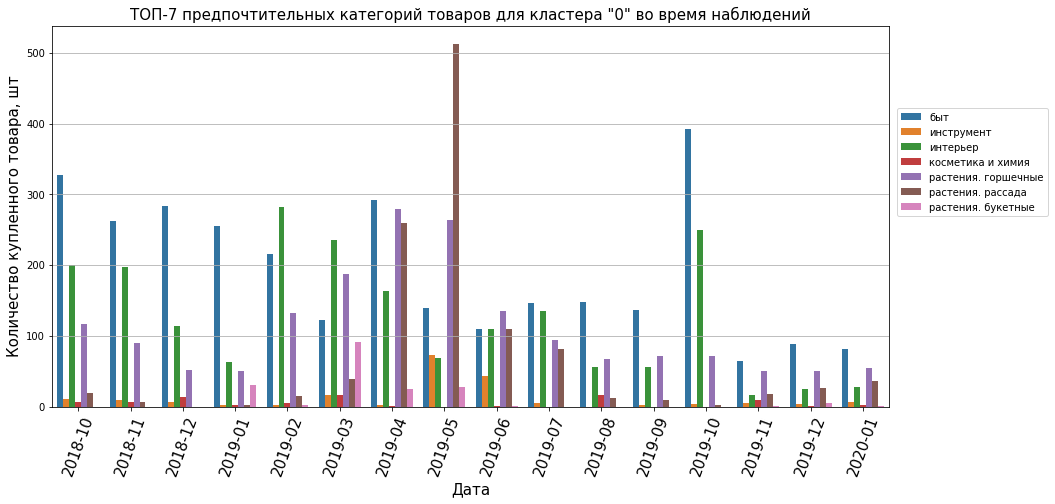

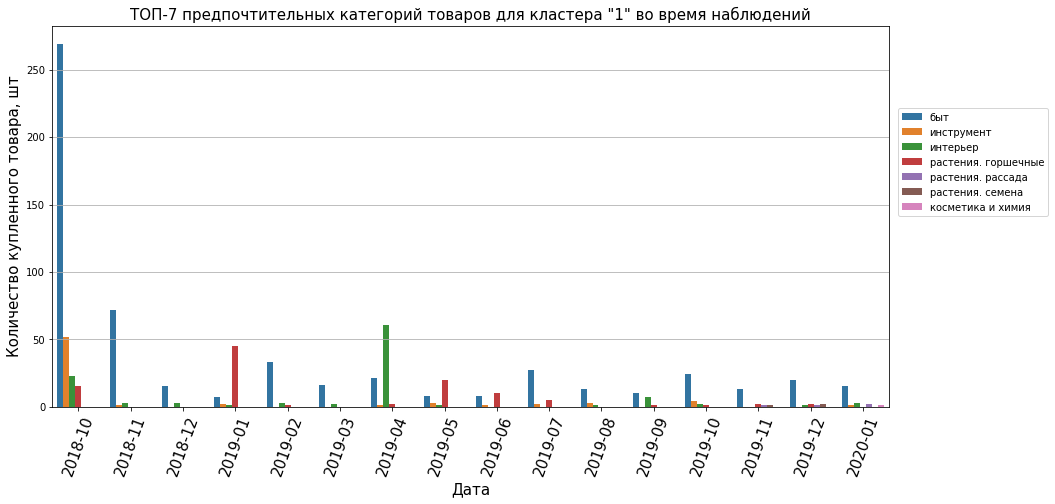

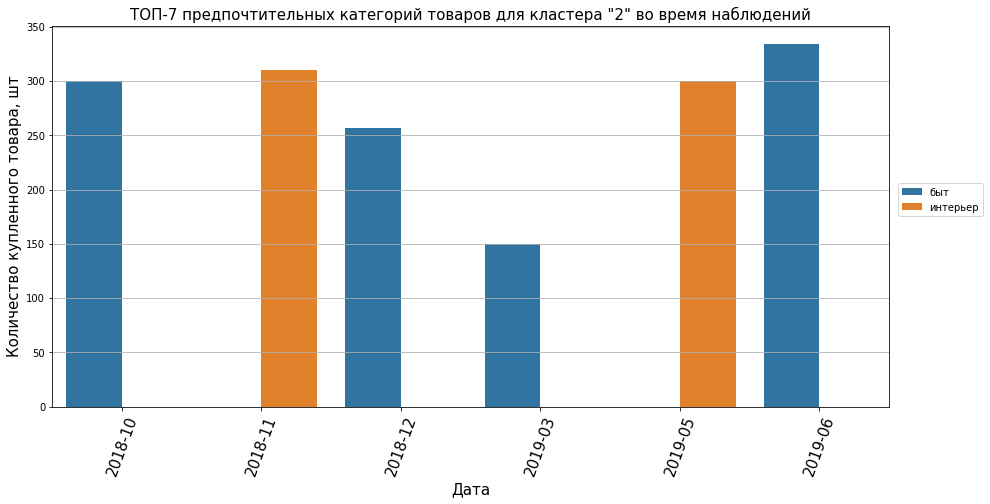

In [87]:
N_TOP_CATEGORIES = 7

for cluster in sorted(data['cluster'].unique()):
    category_by_cluster = (
        data
        .query('cluster == @cluster')
        .groupby(['date_ym','category'], as_index=False).agg({'quantity':'sum'})
        )
    top_category = (
        category_by_cluster
        .groupby('category', as_index=False).agg({'quantity':'sum'})['category']
        .head(N_TOP_CATEGORIES)
    )
    category_by_cluster = category_by_cluster.query('category.isin(@top_category)')
    
    plt.figure(figsize=(15,7))
    #category_by_cluster['date_ym'] = category_by_cluster.date_ym.values.astype('datetime64[M]')
    
    ax = sns.barplot(data=category_by_cluster,x='date_ym',y='quantity',hue='category')
    
    plt.title(f'ТОП-{N_TOP_CATEGORIES} предпочтительных категорий товаров для кластера "{cluster}" во время наблюдений', size=15)
    plt.xlabel('Дата', size=15)
    plt.ylabel('Количество купленного товара, шт', size=15)
    ax.tick_params(axis='x', labelsize=15)
    plt.xticks(rotation=70)
    plt.legend(loc=(1.01,0.5))
    
    plt.grid(axis='y')
    
    plt.show()

<p><span style="color:#455a64;"><b>Кластер 0</b> предпочитает покупать бытовые товары, интерьерные вещи, инструменты, косметику/химию и букетные цветы. Сезонный товар - рассада принадлежит к области интересе этого кластера. Сезон продаж - апрель-май. Так же наблюдается повышение спроса на бытовые товары по октябрям.<br>
<b>Кластер 1</b> В общем спрос довольно низкий, но стабильный. Группы товаров не отличаются от кластера 0<br>
<b>Кластер 2</b> Крупные закупки бытовых товаров с периодичностью в 2-3 месяца.<br>
</span></p>

<h3><span style="color:#455a64;">Проверка гипотез для оценки корректности разбиения на кластеры</span></h3>

<p><span style="color:#455a64;">Для определения типа статистического теста нужно выяснить, относятся ли наши данные к нормально распределенным или нет. Проверим тип распределения при помощи теста Шапиро-Уилка:</span></p>

In [88]:
def check_distrib_by_shap_u(cluster, mean, distrib, alpha):
    stat, pv = stats.shapiro(distrib)
    if pv > alpha:
        print(f'Кластер {cluster}, выборка "{mean:37}": Распределение нормальное')
    else:
        print(f'Кластер {cluster}, выборка "{mean:37}": Распределение ненормальное')

<p><span style="color:#455a64;">Т.к. выборки у нас небольшие, то уровень статистической значимости выбираем низкий: 1%</span></p>

In [89]:
# задаем допустимый уровень статистической значимости

alpha = 0.01

In [90]:
for cluster in total_mean['cluster'].unique():
    for mean in total_mean.drop(['customer_id','cluster','количество_чеков'], axis=1).columns:
        distrib = total_mean.query('cluster == @cluster')[mean]
        check_distrib_by_shap_u(cluster, mean, distrib, alpha)

Кластер 0, выборка "среднее_количество_покупаемых_позиций": Распределение ненормальное
Кластер 0, выборка "средняя_стоимость_покупаемых_товаров ": Распределение ненормальное
Кластер 0, выборка "средний_чек                          ": Распределение ненормальное
Кластер 1, выборка "среднее_количество_покупаемых_позиций": Распределение ненормальное
Кластер 1, выборка "средняя_стоимость_покупаемых_товаров ": Распределение ненормальное
Кластер 1, выборка "средний_чек                          ": Распределение ненормальное
Кластер 2, выборка "среднее_количество_покупаемых_позиций": Распределение нормальное
Кластер 2, выборка "средняя_стоимость_покупаемых_товаров ": Распределение ненормальное
Кластер 2, выборка "средний_чек                          ": Распределение нормальное


<p><span style="color:#455a64;">Как показала проверка, распределение выборок у нас в подавляющем большинстве случаев ненормальное, по ранее построенным боксплотам наблюдаются выбросы, и объем одной из выборок очень мал, поэтому для оценки гипотез должны использоватся непараметрические тесты, одним из которых является тест Манна-Уитни. Его я и буду использовать.</span></p>

In [91]:
# функция попарной проверки гипотез

def check_hps(col):
    for i in range(0,n_clusters-1): # первый перебор от 0 до 3х
        for j in range(i+1,n_clusters): # второй перебор от значения первого до 4х
            # считаем по тесту Манна-Уитни p_value между набором i и j кластера
            pv = stats.mannwhitneyu(total_mean.query('cluster == @i')[col],total_mean.query('cluster == @j')[col]).pvalue
            # выводим заголовок 
            print(f'Проверка гипотезы между кластерами {i} и {j}')
            if pv < alpha: # сверяем p_value и alpha
                print('(-) Нулевая гипотеза отвергается\n')
            else: 
                print('(+) Нулевая гипотеза не отвергается\n')

<h4><span style="color:#455a64;">Гипотеза о среднем чеке</span></h4>


<p><span style="color:#455a64;">Т.к. у нас происходит множественная проверка гипотез, то требуется коррекция уровня значимости. Для вычисления скорректированной alpha воспользуемся методом Бонферрони. Количество проводимых тестов для каждой гипотезы будет равно 3: сочетание из 3х вариантов по 2 элемента.</span></p>

In [92]:
m = 3

alpha_bonf = alpha/m
fwer_bonf = 1-(1-alpha_bonf)**m

print(f'Скорректированный уровень значимости {alpha_bonf}')
print(f'FWER = {fwer_bonf}')

Скорректированный уровень значимости 0.0033333333333333335
FWER = 0.009966703703703561


<p><span style="color:#455a64;">Переопределяем alpha в значение alpha_bonf</span></p>

In [93]:
alpha = alpha_bonf

<p><span style="color:#455a64;">Н<sub>0 </sub>Средний чек покупки статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">H<sub>1</sub> Средний чек статистически отличается между кластерами.</span></p

In [94]:
# проверка гипотез по колонке среднего чека
col = 'средний_чек'
check_hps(col)

Проверка гипотезы между кластерами 0 и 1
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 0 и 2
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 1 и 2
(-) Нулевая гипотеза отвергается



<p><span style="color:#455a64;">Гипотеза о статистическом равенстве среднего чека отвергается</span></p

<h4><span style="color:#455a64;">Гипотеза о среднем количестве позиций в заказе</span></h4>

<p><span style="color:#455a64;">Н<sub>0</sub> Среднее количество приобретаемых позиций статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">Н<sub>1</sub> Среднее количество приобретаемых позиций статистически отличается между кластерами.</span></p>

In [95]:
col = 'среднее_количество_покупаемых_позиций'
check_hps(col)

Проверка гипотезы между кластерами 0 и 1
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 0 и 2
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 1 и 2
(-) Нулевая гипотеза отвергается



<p><span style="color:#455a64;">Все 0-ые гипотезы отвергнуты. Нет оснований пологать, что кластера похожи</span></p

<h4><span style="color:#455a64;">Гипотеза о средней стоимости товаров</span></h4>

<p><span style="color:#455a64;">Н<sub>0</sub> Средняя стоимость покупаемых товаров статистически не отличается между кластерами.</span></p>
                <p><span style="color:#455a64;">Н<sub>1</sub> Средняя стоимость покупаемых товаров статистически отличается между кластерами.</span></p>

In [96]:
col = 'средняя_стоимость_покупаемых_товаров'
check_hps(col)

Проверка гипотезы между кластерами 0 и 1
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 0 и 2
(-) Нулевая гипотеза отвергается

Проверка гипотезы между кластерами 1 и 2
(-) Нулевая гипотеза отвергается



<p><span style="color:#455a64;">Гипотеза о средней стоимости покупаемых товаров отвергается абсолютно</span></p

<h3><span style="color:#455a64;">Итоги сегментирования</span></h3>

<p><span style="color:#455a64;">В результате сегментирования были выделены 3 кластера покупателей. Корректность сегментирования была проверена при помощи средних значений и распределения признаков в получившихся кластерах и проведения попарного статистического теста Манна-Уитни между кластерами. Так же были рассмотрены предпочтения в товарных категориях.<br>
Результат:<br>
<b>0 кластер</b> - типовой посетитель. Активность особо не меняется в течение года. Предпочтения по товарным категориям: бытовые товары, интерьерные вещи, инструменты. Средняя закупка выглядит как 3 позиции одного товара на сумму 485 у.е. Но в апреле-мае имеется повышение спроса на категорию товаров с рассадой. И возможно повышение спроса на бытовые товары в октябре.<br>
<b>1 кластер</b> - по-моему, это тоже типичные покупатели, но предпочитающие товары из более высокой ценовой категории. Средняя покупка так же похожа на  покупку 0ого кластера: 1 товар, 2 позиции, но средний чек 4450 у.е.<br>
<b>2 кластер</b> - возможно, оптовый покупатель, который с периодичностью в 2-3 месяца проводит крупную закупку товара, но есть одно "НО": customer_id ни разу не совпадает. Т.е. можно предположить, что это разные покупатели. Или один и тот же, но покупающий под разными именами. Его средний заказ: 190+ позиций, 16450 у.е. </span></p

<h2><span style="color:#455a64;">Рекомендации</span></h2>

<p><span style="color:#455a64;">
Рассмотрев получившиеся портреты покупателей по кластерам можно предложить следующие варианты персонализированных бонусов и акций:<br>
    <b>для кластера 0:</b> должна легко зайти акция 4 товара по цене 3 (или 5 по цене 4. Вариативность существует) с небольшим увеличением стоимости непосредственно товара, участвующего в акции. Предложение из первой иттерации о скидке на следующую покупку определенного товара или категории - то же имеет место быть.Собственно, эти акцию можно использовать в первых 2 кластерах. Так же, т.к. присутствует сезонность, то можно начинать завлекать покупателя заранее: проводить рекламную рассылку, каталог товара из категории рассады и сопутствующих товаров для приусадебного хозяйства. Сезонные акции \"рассада + удобрения\" помогут повысить средний чек и ввести в ассортимент новые позиции. Но т.к. доля прибыли от этой категории около всего 3%, предложение требует оценки окупаемости. Так же стоит обратить внимание на представление товаров из категории "Быт" в конце сентября-начале октября. Небольшой агрессивный маркетинг в это время не помешает.<br>
    <b>для кластера 1:</b> возможно, для этой категории покупателей можно ввести премиальные программы: приоритеный заказ товара, приоритетная доставка. Примиальная программа может быть как бесплатной, при условии выполнения определенных условий, например, сумме покупок в месяц не менее, чем на 10000 у.е., так и платной.<br>
    <b>для кластера 2:</b> для таких оптовых клиентов требуется особое отношение: я бы предложил выделять им личного менеджера который будет консультировать по товару и его наличию, потому что на складе может не оказаться нужного клиенту количества товара и это будет негативный опыт для него. Если же заказ будет сделан через менеджера и заранее, у магазина может появиться лаг времени для пополнения запасов. Так же должны быть скидки за объем. <br>
    <b>Общее:</b> падение продаж никуда не делось, как и покупатели с одним заказом. Поэтому следует узнать причины этого падения. Построить воронку продаж, посмотреть на каком этапе покупатели отваливаются, почему возврат их крайне низок.
</span></p>

